#  FIFA World Cup 2026 — Análisis Predictivo Avanzado
---
**Estudiante:** *Giaan Harri Chavez Bazan* &nbsp;|&nbsp; **Fecha:** Julio 2026

**Dataset histórico:** `results.csv` · `goalscorers.csv` · `shootouts.csv` · `former_names.csv` (1872–2026)

**Fuente de resultados del torneo:** FIFA.com — [Standings oficiales](https://www.fifa.com/es/tournaments/mens/worldcup/canadamexicousa2026/standings) — contrastado con ESPN / Yahoo Sports / NBC Sports (12 jul 2026).

**Objetivo:** Entrenar tres modelos predictivos (Poisson, XGBoost, Monte Carlo) sobre el historial completo de fútbol internacional para:
1. Reconstruir y **validar** el modelo contra los resultados **reales** de Fase de Grupos, Ronda de 32, Octavos y Cuartos de Final (100 partidos ya jugados).
2. **Predecir de verdad** lo único que aún no se ha jugado: **Semifinales** y **Final**.
3. Estimar la **probabilidad de campeón** para cada uno de los 4 semifinalistas.

---

## 📋 Tabla de Contenidos
1. [Configuración del Entorno](#1)
2. [Carga y Exploración de Datos (EDA)](#2)
3. [Fase de Grupos Real WC2026 (72 partidos) + Tablas de Posiciones](#3)
4. [Ronda de 32: Clasificados Reales](#4)
5. [Resultados Reales: Ronda de 32 → Octavos → Cuartos (28 partidos)](#5)
6. [Ingeniería de Features: ELO + Forma Reciente](#6)
7. [Modelos Predictivos (Poisson · XGBoost · Monte Carlo)](#7)
8. [Validación del Modelo vs. 100 Partidos Reales](#8)
9. [Visualización del Bracket Real (16avos → Cuartos)](#9)
10. [🔮 Predicción: Semifinales, Tercer Puesto y Final](#10)
11. [🏆 Simulación Monte Carlo: Probabilidad de Campeón](#11)
12. [Conclusiones y Resumen Ejecutivo](#12)


## 1. Configuración del Entorno <a id='1'></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 1 — Instalación y configuración del entorno
# ══════════════════════════════════════════════════════════════════════════════
!pip install -q xgboost scikit-learn scipy statsmodels seaborn matplotlib pandas numpy openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import scipy.special
import time
from scipy.stats import poisson
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score
from xgboost import XGBRegressor
from itertools import combinations

warnings.filterwarnings('ignore')

# ── Estilo visual profesional (tema oscuro) ───────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#c9d1d9',
    'ytick.color': '#c9d1d9',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.alpha': 0.6,
    'axes.titlesize': 13,
    'axes.labelsize': 10,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})
C = ['#58a6ff','#f0883e','#3fb950','#ff7b72','#d2a8ff','#79c0ff','#ffa657','#e3b341']
print('✅ Entorno configurado | NumPy', np.__version__, '| Pandas', pd.__version__)


✅ Entorno configurado | NumPy 2.0.2 | Pandas 2.2.2


## 2. Carga y Exploración de Datos (EDA) <a id='2'></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 2 — Carga de datos históricos desde Google Colab
# ══════════════════════════════════════════════════════════════════════════════
from google.colab import files
print('📂 Sube los 4 archivos CSV: results.csv, goalscorers.csv, shootouts.csv, former_names.csv')
uploaded = files.upload()

df_results   = pd.read_csv('results.csv',     parse_dates=['date'])
df_goals     = pd.read_csv('goalscorers.csv',  parse_dates=['date'])
df_shootouts = pd.read_csv('shootouts.csv',    parse_dates=['date'])
df_names     = pd.read_csv('former_names.csv')

# ── Normalización de nombres históricos ──────────────────────────────────────
name_map = dict(zip(df_names['former'], df_names['current']))
for col in ['home_team', 'away_team']:
    df_results[col] = df_results[col].replace(name_map)
    df_goals[col]   = df_goals[col].replace(name_map)

print(f'\n✅ results.csv    : {len(df_results):,} partidos ({df_results["date"].dt.year.min()}–{df_results["date"].dt.year.max()})')
print(f'✅ goalscorers.csv: {len(df_goals):,} goles registrados')
print(f'✅ shootouts.csv  : {len(df_shootouts):,} definiciones por penales')
print(f'✅ former_names   : {len(df_names)} registros de renombres históricos')
print(f'\n📅 Último partido registrado: {df_results["date"].max().date()}')


📂 Sube los 4 archivos CSV: results.csv, goalscorers.csv, shootouts.csv, former_names.csv


Saving former_names.csv to former_names.csv
Saving goalscorers.csv to goalscorers.csv
Saving results.csv to results.csv
Saving shootouts.csv to shootouts.csv

✅ results.csv    : 49,477 partidos (1872–2026)
✅ goalscorers.csv: 47,747 goles registrados
✅ shootouts.csv  : 678 definiciones por penales
✅ former_names   : 36 registros de renombres históricos

📅 Último partido registrado: 2026-06-27


## 3. Fase de Grupos Real WC2026 (72 partidos) + Tablas de Posiciones <a id='3'></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 3 — Grupos oficiales WC2026 + resultados REALES y completos de Fase de Grupos
# Fuente: FIFA.com / ESPN / Yahoo Sports — verificado 12 julio 2026 (72/72 partidos)
# ══════════════════════════════════════════════════════════════════════════════

GRUPOS_WC2026 = {
    'A': ['Mexico', 'South Africa', 'Czech Republic', 'South Korea'],
    'B': ['Switzerland', 'Canada', 'Bosnia and Herzegovina', 'Qatar'],
    'C': ['Brazil', 'Morocco', 'Scotland', 'Haiti'],
    'D': ['United States', 'Australia', 'Turkey', 'Paraguay'],
    'E': ['Germany', 'Ivory Coast', 'Ecuador', 'Curaçao'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Uruguay', 'Saudi Arabia'],
    'I': ['France', 'Norway', 'Senegal', 'Iraq'],
    'J': ['Argentina', 'Austria', 'Algeria', 'Jordan'],
    'K': ['Colombia', 'Portugal', 'DR Congo', 'Uzbekistan'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama'],
}

all_wc_teams = sorted(set(t for g in GRUPOS_WC2026.values() for t in g))
print(f'📊 Total selecciones: {len(all_wc_teams)}')

# ── Resultados REALES y COMPLETOS de la Fase de Grupos WC2026 (72/72) ─────────
RESULTADOS_REALES_GS = [
    # GRUPO A
    {'date':'2026-06-11','home_team':'Mexico','away_team':'South Africa','home_score':2,'away_score':0,'grupo':'A'},
    {'date':'2026-06-11','home_team':'South Korea','away_team':'Czech Republic','home_score':2,'away_score':1,'grupo':'A'},
    {'date':'2026-06-18','home_team':'Czech Republic','away_team':'South Africa','home_score':1,'away_score':1,'grupo':'A'},
    {'date':'2026-06-18','home_team':'Mexico','away_team':'South Korea','home_score':1,'away_score':0,'grupo':'A'},
    {'date':'2026-06-24','home_team':'Mexico','away_team':'Czech Republic','home_score':3,'away_score':0,'grupo':'A'},
    {'date':'2026-06-24','home_team':'South Africa','away_team':'South Korea','home_score':1,'away_score':0,'grupo':'A'},
    # GRUPO B
    {'date':'2026-06-12','home_team':'Canada','away_team':'Bosnia and Herzegovina','home_score':1,'away_score':1,'grupo':'B'},
    {'date':'2026-06-13','home_team':'Qatar','away_team':'Switzerland','home_score':1,'away_score':1,'grupo':'B'},
    {'date':'2026-06-18','home_team':'Switzerland','away_team':'Bosnia and Herzegovina','home_score':4,'away_score':1,'grupo':'B'},
    {'date':'2026-06-18','home_team':'Canada','away_team':'Qatar','home_score':6,'away_score':0,'grupo':'B'},
    {'date':'2026-06-24','home_team':'Switzerland','away_team':'Canada','home_score':2,'away_score':1,'grupo':'B'},
    {'date':'2026-06-24','home_team':'Bosnia and Herzegovina','away_team':'Qatar','home_score':3,'away_score':1,'grupo':'B'},
    # GRUPO C
    {'date':'2026-06-13','home_team':'Brazil','away_team':'Morocco','home_score':1,'away_score':1,'grupo':'C'},
    {'date':'2026-06-13','home_team':'Haiti','away_team':'Scotland','home_score':0,'away_score':1,'grupo':'C'},
    {'date':'2026-06-19','home_team':'Scotland','away_team':'Morocco','home_score':0,'away_score':1,'grupo':'C'},
    {'date':'2026-06-19','home_team':'Brazil','away_team':'Haiti','home_score':3,'away_score':0,'grupo':'C'},
    {'date':'2026-06-24','home_team':'Scotland','away_team':'Brazil','home_score':0,'away_score':3,'grupo':'C'},
    {'date':'2026-06-24','home_team':'Morocco','away_team':'Haiti','home_score':4,'away_score':2,'grupo':'C'},
    # GRUPO D
    {'date':'2026-06-12','home_team':'United States','away_team':'Paraguay','home_score':4,'away_score':1,'grupo':'D'},
    {'date':'2026-06-13','home_team':'Australia','away_team':'Turkey','home_score':2,'away_score':0,'grupo':'D'},
    {'date':'2026-06-19','home_team':'United States','away_team':'Australia','home_score':2,'away_score':0,'grupo':'D'},
    {'date':'2026-06-19','home_team':'Turkey','away_team':'Paraguay','home_score':0,'away_score':1,'grupo':'D'},
    {'date':'2026-06-25','home_team':'Turkey','away_team':'United States','home_score':3,'away_score':2,'grupo':'D'},
    {'date':'2026-06-25','home_team':'Paraguay','away_team':'Australia','home_score':0,'away_score':0,'grupo':'D'},
    # GRUPO E
    {'date':'2026-06-14','home_team':'Germany','away_team':'Curaçao','home_score':7,'away_score':1,'grupo':'E'},
    {'date':'2026-06-14','home_team':'Ivory Coast','away_team':'Ecuador','home_score':1,'away_score':0,'grupo':'E'},
    {'date':'2026-06-20','home_team':'Germany','away_team':'Ivory Coast','home_score':2,'away_score':1,'grupo':'E'},
    {'date':'2026-06-20','home_team':'Ecuador','away_team':'Curaçao','home_score':0,'away_score':0,'grupo':'E'},
    {'date':'2026-06-25','home_team':'Ecuador','away_team':'Germany','home_score':2,'away_score':1,'grupo':'E'},
    {'date':'2026-06-25','home_team':'Curaçao','away_team':'Ivory Coast','home_score':0,'away_score':2,'grupo':'E'},
    # GRUPO F
    {'date':'2026-06-14','home_team':'Netherlands','away_team':'Japan','home_score':2,'away_score':2,'grupo':'F'},
    {'date':'2026-06-14','home_team':'Sweden','away_team':'Tunisia','home_score':5,'away_score':1,'grupo':'F'},
    {'date':'2026-06-20','home_team':'Netherlands','away_team':'Sweden','home_score':5,'away_score':1,'grupo':'F'},
    {'date':'2026-06-20','home_team':'Tunisia','away_team':'Japan','home_score':0,'away_score':4,'grupo':'F'},
    {'date':'2026-06-25','home_team':'Japan','away_team':'Sweden','home_score':1,'away_score':1,'grupo':'F'},
    {'date':'2026-06-25','home_team':'Tunisia','away_team':'Netherlands','home_score':1,'away_score':3,'grupo':'F'},
    # GRUPO G
    {'date':'2026-06-15','home_team':'Belgium','away_team':'Egypt','home_score':1,'away_score':1,'grupo':'G'},
    {'date':'2026-06-15','home_team':'Iran','away_team':'New Zealand','home_score':2,'away_score':2,'grupo':'G'},
    {'date':'2026-06-21','home_team':'Belgium','away_team':'Iran','home_score':0,'away_score':0,'grupo':'G'},
    {'date':'2026-06-21','home_team':'New Zealand','away_team':'Egypt','home_score':1,'away_score':3,'grupo':'G'},
    {'date':'2026-06-26','home_team':'Egypt','away_team':'Iran','home_score':1,'away_score':1,'grupo':'G'},
    {'date':'2026-06-26','home_team':'New Zealand','away_team':'Belgium','home_score':1,'away_score':5,'grupo':'G'},
    # GRUPO H
    {'date':'2026-06-15','home_team':'Spain','away_team':'Cape Verde','home_score':0,'away_score':0,'grupo':'H'},
    {'date':'2026-06-15','home_team':'Saudi Arabia','away_team':'Uruguay','home_score':1,'away_score':1,'grupo':'H'},
    {'date':'2026-06-21','home_team':'Spain','away_team':'Saudi Arabia','home_score':4,'away_score':0,'grupo':'H'},
    {'date':'2026-06-21','home_team':'Uruguay','away_team':'Cape Verde','home_score':2,'away_score':2,'grupo':'H'},
    {'date':'2026-06-26','home_team':'Cape Verde','away_team':'Saudi Arabia','home_score':0,'away_score':0,'grupo':'H'},
    {'date':'2026-06-26','home_team':'Uruguay','away_team':'Spain','home_score':0,'away_score':1,'grupo':'H'},
    # GRUPO I
    {'date':'2026-06-16','home_team':'France','away_team':'Senegal','home_score':3,'away_score':1,'grupo':'I'},
    {'date':'2026-06-16','home_team':'Iraq','away_team':'Norway','home_score':1,'away_score':4,'grupo':'I'},
    {'date':'2026-06-22','home_team':'France','away_team':'Iraq','home_score':3,'away_score':0,'grupo':'I'},
    {'date':'2026-06-22','home_team':'Norway','away_team':'Senegal','home_score':3,'away_score':2,'grupo':'I'},
    {'date':'2026-06-26','home_team':'Norway','away_team':'France','home_score':1,'away_score':4,'grupo':'I'},
    {'date':'2026-06-26','home_team':'Senegal','away_team':'Iraq','home_score':5,'away_score':0,'grupo':'I'},
    # GRUPO J
    {'date':'2026-06-16','home_team':'Argentina','away_team':'Algeria','home_score':3,'away_score':0,'grupo':'J'},
    {'date':'2026-06-16','home_team':'Austria','away_team':'Jordan','home_score':3,'away_score':1,'grupo':'J'},
    {'date':'2026-06-22','home_team':'Argentina','away_team':'Austria','home_score':2,'away_score':0,'grupo':'J'},
    {'date':'2026-06-22','home_team':'Jordan','away_team':'Algeria','home_score':1,'away_score':2,'grupo':'J'},
    {'date':'2026-06-27','home_team':'Jordan','away_team':'Argentina','home_score':1,'away_score':3,'grupo':'J'},
    {'date':'2026-06-27','home_team':'Algeria','away_team':'Austria','home_score':3,'away_score':3,'grupo':'J'},
    # GRUPO K
    {'date':'2026-06-17','home_team':'Portugal','away_team':'DR Congo','home_score':1,'away_score':1,'grupo':'K'},
    {'date':'2026-06-17','home_team':'Uzbekistan','away_team':'Colombia','home_score':1,'away_score':3,'grupo':'K'},
    {'date':'2026-06-23','home_team':'Portugal','away_team':'Uzbekistan','home_score':5,'away_score':0,'grupo':'K'},
    {'date':'2026-06-23','home_team':'Colombia','away_team':'DR Congo','home_score':1,'away_score':0,'grupo':'K'},
    {'date':'2026-06-27','home_team':'Colombia','away_team':'Portugal','home_score':0,'away_score':0,'grupo':'K'},
    {'date':'2026-06-27','home_team':'DR Congo','away_team':'Uzbekistan','home_score':3,'away_score':1,'grupo':'K'},
    # GRUPO L
    {'date':'2026-06-17','home_team':'England','away_team':'Croatia','home_score':4,'away_score':2,'grupo':'L'},
    {'date':'2026-06-17','home_team':'Ghana','away_team':'Panama','home_score':1,'away_score':0,'grupo':'L'},
    {'date':'2026-06-23','home_team':'England','away_team':'Ghana','home_score':0,'away_score':0,'grupo':'L'},
    {'date':'2026-06-23','home_team':'Panama','away_team':'Croatia','home_score':0,'away_score':1,'grupo':'L'},
    {'date':'2026-06-27','home_team':'Panama','away_team':'England','home_score':0,'away_score':2,'grupo':'L'},
    {'date':'2026-06-27','home_team':'Croatia','away_team':'Ghana','home_score':2,'away_score':1,'grupo':'L'},
]

df_gs_real = pd.DataFrame(RESULTADOS_REALES_GS)
df_gs_real['date'] = pd.to_datetime(df_gs_real['date'])

print(f'📊 Partidos de fase de grupos WC2026 registrados: {len(df_gs_real)}/72')
print(f'   Grupos completados: 12/12 ✅')
print(f'   Total goles marcados: {df_gs_real["home_score"].sum() + df_gs_real["away_score"].sum()}')
print(f'   Promedio goles/partido: {(df_gs_real["home_score"].sum() + df_gs_real["away_score"].sum()) / len(df_gs_real):.2f}')


📊 Total selecciones: 48
📊 Partidos de fase de grupos WC2026 registrados: 72/72
   Grupos completados: 12/12 ✅
   Total goles marcados: 215
   Promedio goles/partido: 2.99


## 4. Ronda de 32 — Clasificados Reales <a id='4'></a>

  CLASIFICADOS A LA RONDA DE 32 — FIFA WORLD CUP 2026 (REAL)
  Grupo A: 1° Mexico                   2° South Africa
  Grupo B: 1° Switzerland              2° Canada
  Grupo C: 1° Brazil                   2° Morocco
  Grupo D: 1° United States            2° Australia
  Grupo E: 1° Germany                  2° Ivory Coast
  Grupo F: 1° Netherlands              2° Japan
  Grupo G: 1° Belgium                  2° Egypt
  Grupo H: 1° Spain                    2° Cape Verde
  Grupo I: 1° France                   2° Norway
  Grupo J: 1° Argentina                2° Austria
  Grupo K: 1° Colombia                 2° Portugal
  Grupo L: 1° England                  2° Croatia

  Mejores 8 terceros:
    3B: Bosnia and Herzegovina
    3D: Paraguay
    3E: Ecuador
    3F: Sweden
    3I: Senegal
    3J: Algeria
    3K: DR Congo
    3L: Ghana


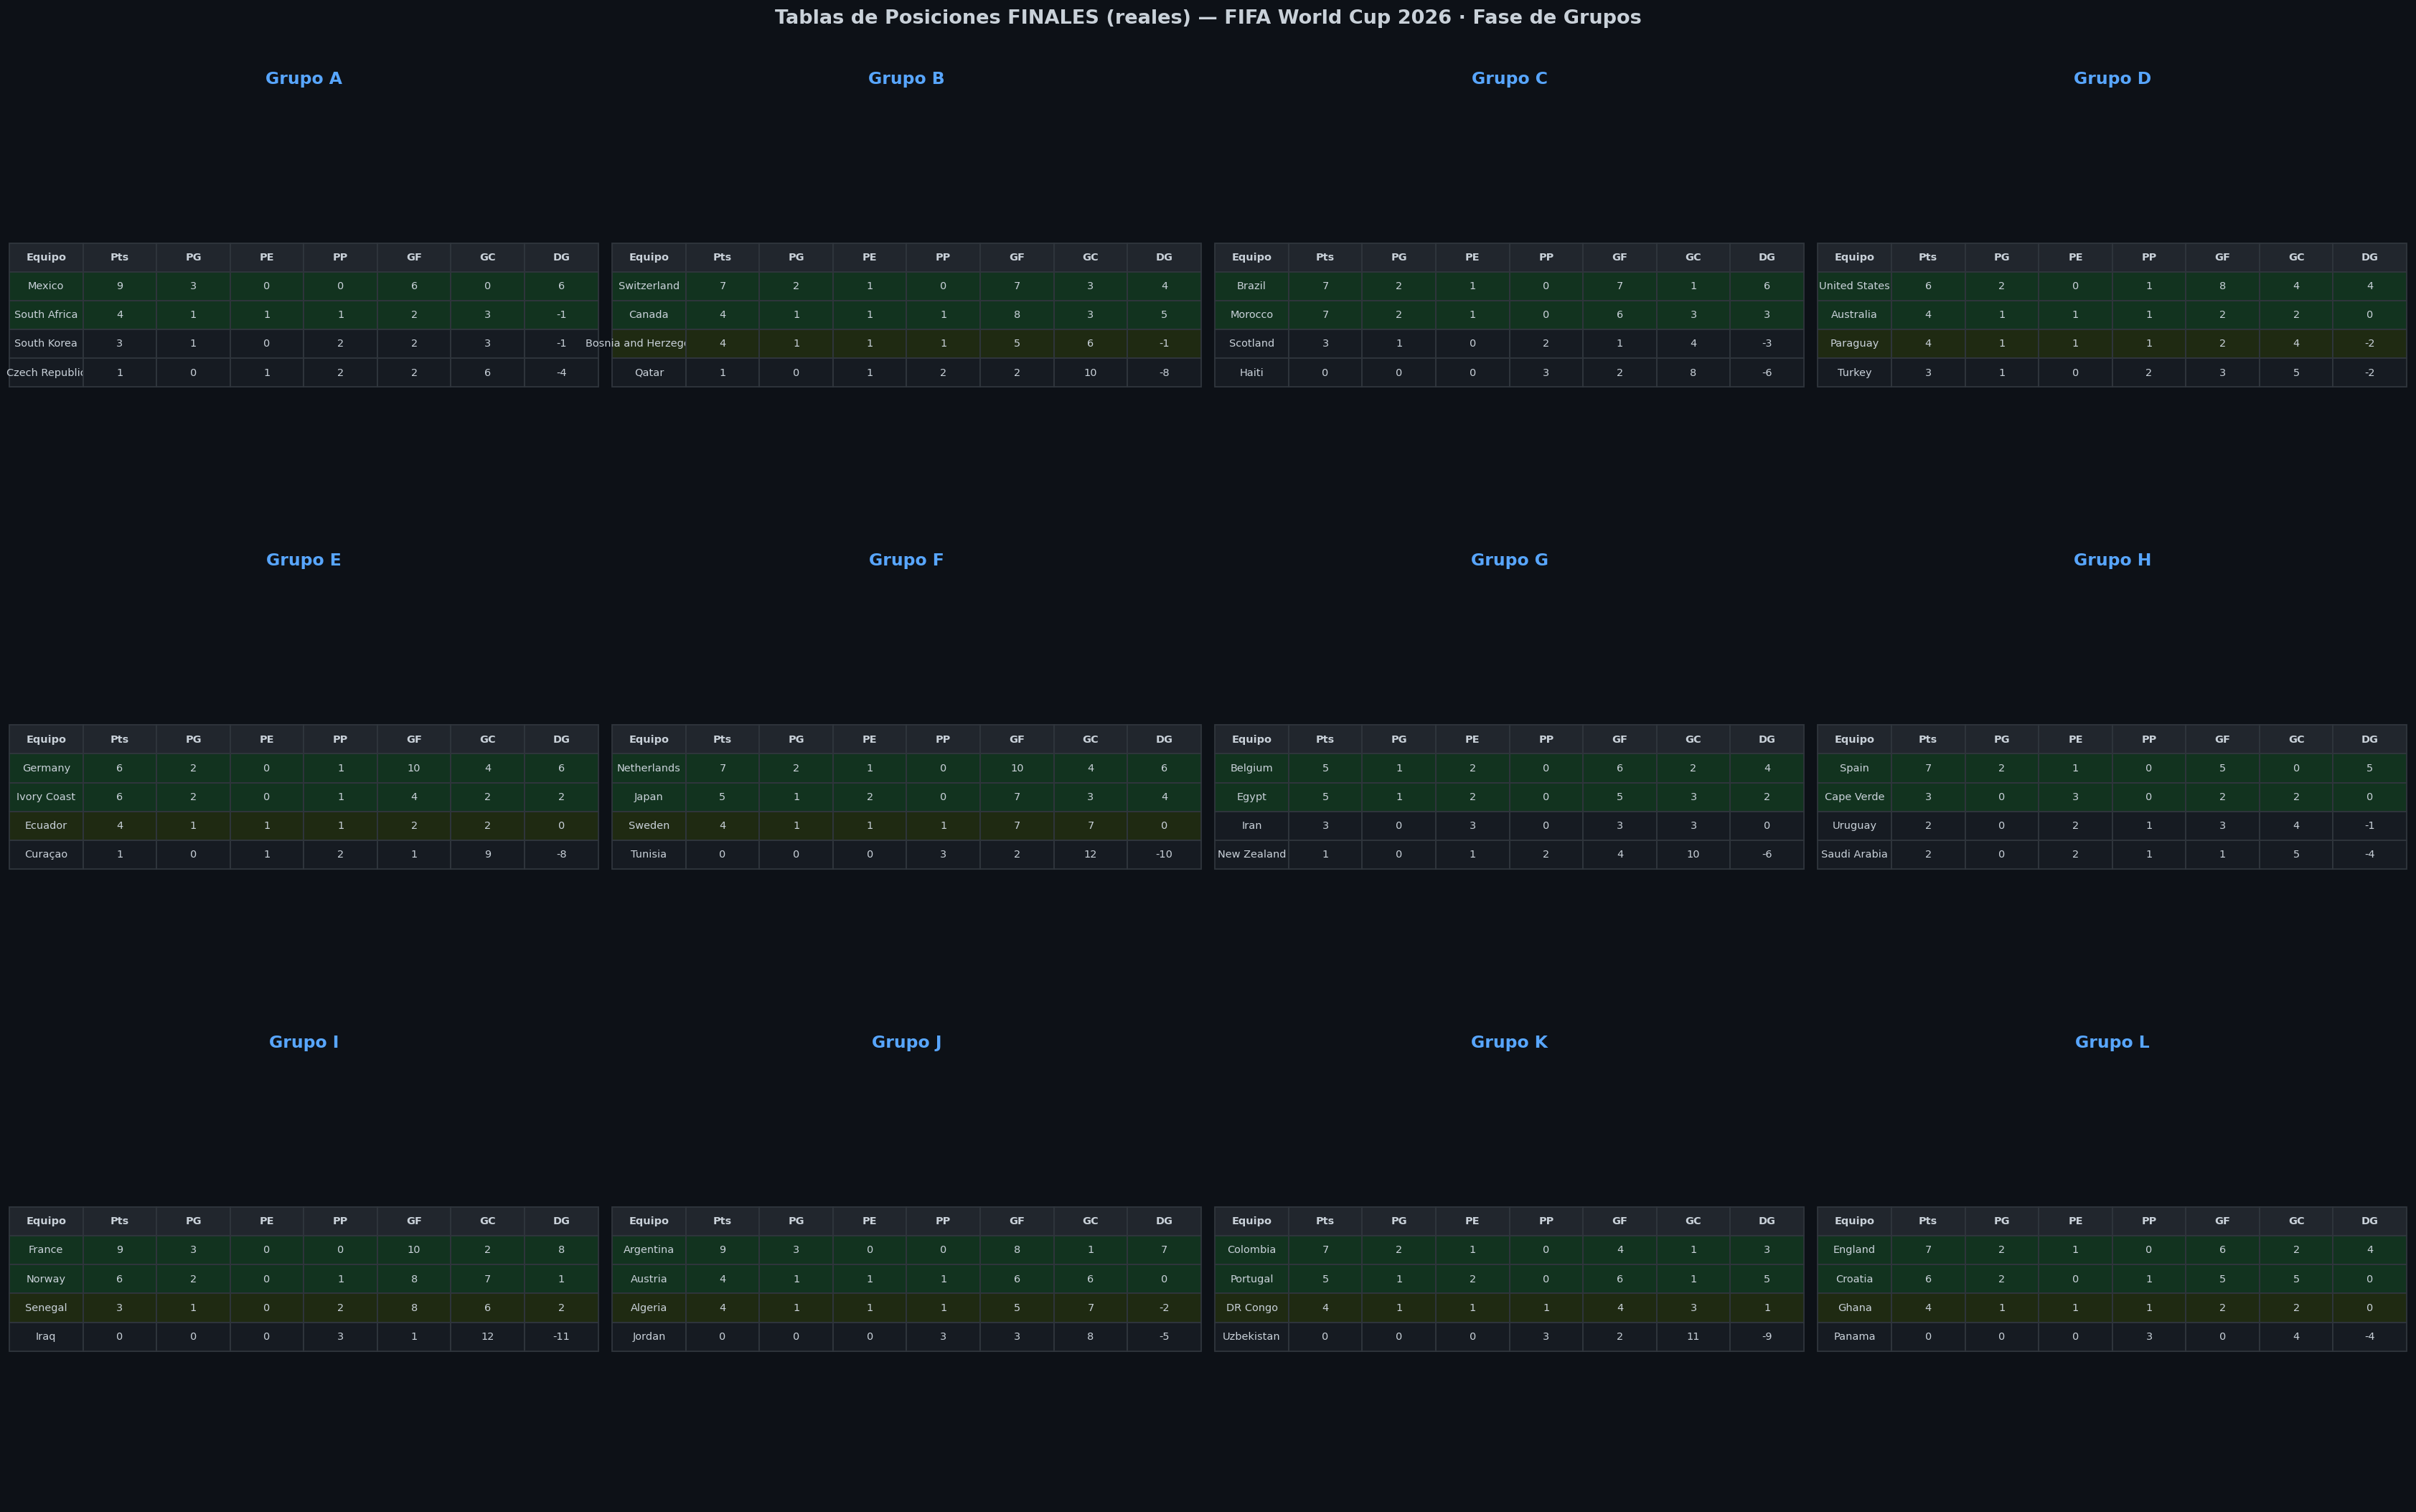

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 4 — Tablas de posición reales + los 32 clasificados reales y confirmados
# ══════════════════════════════════════════════════════════════════════════════

def calcular_tabla_real(grupo, equipos, df_real):
    tabla = {t: {'PJ':0,'PG':0,'PE':0,'PP':0,'GF':0,'GC':0,'DG':0,'Pts':0}
             for t in equipos}
    partidos_g = df_real[df_real['grupo'] == grupo]
    for _, r in partidos_g.iterrows():
        h, a = r['home_team'], r['away_team']
        gh, ga = int(r['home_score']), int(r['away_score'])
        for tm, gf, gc in [(h,gh,ga),(a,ga,gh)]:
            if tm in tabla:
                tabla[tm]['PJ']+=1; tabla[tm]['GF']+=gf; tabla[tm]['GC']+=gc
                tabla[tm]['DG']+=gf-gc
                if gf>gc:    tabla[tm]['PG']+=1; tabla[tm]['Pts']+=3
                elif gf==gc: tabla[tm]['PE']+=1; tabla[tm]['Pts']+=1
                else:        tabla[tm]['PP']+=1
    return (pd.DataFrame(tabla).T
              .sort_values(['Pts','DG','GF'], ascending=False)
              .reset_index().rename(columns={'index':'Equipo'}))

tablas_reales = {g: calcular_tabla_real(g, eqs, df_gs_real) for g, eqs in GRUPOS_WC2026.items()}

# ── Clasificados reales confirmados (FIFA / ESPN / Yahoo — 12 jul 2026) ───────
# Top-2 de cada grupo + los 8 mejores terceros. Los 32 nombres coinciden
# exactamente con el campo real de la Ronda de 32 (verificado contra ESPN).
CLASIFICADOS_R32 = {
    'A1':'Mexico','A2':'South Africa',
    'B1':'Switzerland','B2':'Canada',
    'C1':'Brazil','C2':'Morocco',
    'D1':'United States','D2':'Australia',
    'E1':'Germany','E2':'Ivory Coast',
    'F1':'Netherlands','F2':'Japan',
    'G1':'Belgium','G2':'Egypt',
    'H1':'Spain','H2':'Cape Verde',
    'I1':'France','I2':'Norway',
    'J1':'Argentina','J2':'Austria',
    'K1':'Colombia','K2':'Portugal',
    'L1':'England','L2':'Croatia',
    # 8 mejores terceros — todos confirmados ✅
    '3B':'Bosnia and Herzegovina',
    '3D':'Paraguay',
    '3E':'Ecuador',
    '3F':'Sweden',
    '3I':'Senegal',
    '3J':'Algeria',
    '3K':'DR Congo',
    '3L':'Ghana',
}
assert len(set(CLASIFICADOS_R32.values())) == 32, 'Deben ser 32 clasificados únicos'

print('='*68)
print('  CLASIFICADOS A LA RONDA DE 32 — FIFA WORLD CUP 2026 (REAL)')
print('='*68)
for grupo in 'ABCDEFGHIJKL':
    k1, k2 = f'{grupo}1', f'{grupo}2'
    print(f'  Grupo {grupo}: 1° {CLASIFICADOS_R32[k1]:<24} 2° {CLASIFICADOS_R32[k2]}')
print('\n  Mejores 8 terceros:')
for k in ['3B','3D','3E','3F','3I','3J','3K','3L']:
    print(f'    {k}: {CLASIFICADOS_R32[k]}')

# ── Visualización de tablas finales ──────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(26, 16))
fig.suptitle('Tablas de Posiciones FINALES (reales) — FIFA World Cup 2026 · Fase de Grupos',
             fontsize=15, fontweight='bold', y=1.01)
COLS_T = ['Equipo','Pts','PG','PE','PP','GF','GC','DG']
terceros_clasificados = set(CLASIFICADOS_R32[k] for k in ['3B','3D','3E','3F','3I','3J','3K','3L'])
for ax, (grupo, tbl) in zip(axes.flat, tablas_reales.items()):
    ax.axis('off')
    ax.set_title(f'Grupo {grupo}', fontweight='bold', color=C[0])
    filas = tbl[COLS_T].values.tolist()
    row_colors = []
    for i, eq in enumerate(tbl['Equipo']):
        if i < 2:
            row_colors.append('#12331f')
        elif eq in terceros_clasificados:
            row_colors.append('#1f2a12')
        else:
            row_colors.append('#161b22')
    tabla_mpl = ax.table(cellText=filas, colLabels=COLS_T, loc='center', cellLoc='center')
    tabla_mpl.auto_set_font_size(False); tabla_mpl.set_fontsize(8); tabla_mpl.scale(1, 1.4)
    for (r, c_), cell in tabla_mpl.get_celld().items():
        cell.set_edgecolor('#30363d')
        if r == 0:
            cell.set_facecolor('#21262d'); cell.set_text_props(color='#c9d1d9', fontweight='bold')
        else:
            cell.set_facecolor(row_colors[r-1]); cell.set_text_props(color='#c9d1d9')
plt.tight_layout()
plt.savefig('tablas_grupos_wc2026.png', bbox_inches='tight', facecolor='#0d1117', dpi=140)
plt.show()


## 5. Resultados Reales: Ronda de 32 → Octavos → Cuartos (28 partidos) <a id='5'></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 5 — Resultados REALES de las 3 rondas de eliminación ya jugadas
# Fuente: ESPN (espn.com/soccer/story/_/id/48939282) — verificado 12 julio 2026
# 'ganador' = equipo que avanzó (considerando penales cuando aplica)
# ══════════════════════════════════════════════════════════════════════════════

RESULTADOS_R32_REAL = [
    {'date':'2026-06-28','ronda':'R32','home_team':'South Africa','away_team':'Canada','home_score':0,'away_score':1,'ganador':'Canada','penales':False,'sede':'Inglewood'},
    {'date':'2026-06-29','ronda':'R32','home_team':'Brazil','away_team':'Japan','home_score':2,'away_score':1,'ganador':'Brazil','penales':False,'sede':'Houston'},
    {'date':'2026-06-29','ronda':'R32','home_team':'Germany','away_team':'Paraguay','home_score':1,'away_score':1,'ganador':'Paraguay','penales':True,'sede':'Foxborough'},
    {'date':'2026-06-29','ronda':'R32','home_team':'Netherlands','away_team':'Morocco','home_score':1,'away_score':1,'ganador':'Morocco','penales':True,'sede':'Guadalajara'},
    {'date':'2026-06-30','ronda':'R32','home_team':'Ivory Coast','away_team':'Norway','home_score':1,'away_score':2,'ganador':'Norway','penales':False,'sede':'Arlington'},
    {'date':'2026-06-30','ronda':'R32','home_team':'France','away_team':'Sweden','home_score':3,'away_score':0,'ganador':'France','penales':False,'sede':'East Rutherford'},
    {'date':'2026-06-30','ronda':'R32','home_team':'Mexico','away_team':'Ecuador','home_score':2,'away_score':0,'ganador':'Mexico','penales':False,'sede':'Mexico City'},
    {'date':'2026-07-01','ronda':'R32','home_team':'England','away_team':'DR Congo','home_score':2,'away_score':1,'ganador':'England','penales':False,'sede':'Atlanta'},
    {'date':'2026-07-01','ronda':'R32','home_team':'Belgium','away_team':'Senegal','home_score':3,'away_score':2,'ganador':'Belgium','penales':False,'sede':'Seattle'},
    {'date':'2026-07-01','ronda':'R32','home_team':'United States','away_team':'Bosnia and Herzegovina','home_score':2,'away_score':0,'ganador':'United States','penales':False,'sede':'Santa Clara'},
    {'date':'2026-07-02','ronda':'R32','home_team':'Spain','away_team':'Austria','home_score':3,'away_score':0,'ganador':'Spain','penales':False,'sede':'Inglewood'},
    {'date':'2026-07-02','ronda':'R32','home_team':'Portugal','away_team':'Croatia','home_score':2,'away_score':1,'ganador':'Portugal','penales':False,'sede':'Toronto'},
    {'date':'2026-07-02','ronda':'R32','home_team':'Switzerland','away_team':'Algeria','home_score':2,'away_score':0,'ganador':'Switzerland','penales':False,'sede':'Vancouver'},
    {'date':'2026-07-03','ronda':'R32','home_team':'Australia','away_team':'Egypt','home_score':1,'away_score':1,'ganador':'Egypt','penales':True,'sede':'Arlington'},
    {'date':'2026-07-03','ronda':'R32','home_team':'Argentina','away_team':'Cape Verde','home_score':3,'away_score':2,'ganador':'Argentina','penales':False,'sede':'Miami Gardens'},
    {'date':'2026-07-03','ronda':'R32','home_team':'Colombia','away_team':'Ghana','home_score':1,'away_score':0,'ganador':'Colombia','penales':False,'sede':'Kansas City'},
]

RESULTADOS_R16_REAL = [
    {'date':'2026-07-04','ronda':'R16','home_team':'Canada','away_team':'Morocco','home_score':0,'away_score':3,'ganador':'Morocco','penales':False,'sede':'Houston'},
    {'date':'2026-07-04','ronda':'R16','home_team':'Paraguay','away_team':'France','home_score':0,'away_score':1,'ganador':'France','penales':False,'sede':'Philadelphia'},
    {'date':'2026-07-05','ronda':'R16','home_team':'Brazil','away_team':'Norway','home_score':1,'away_score':2,'ganador':'Norway','penales':False,'sede':'East Rutherford'},
    {'date':'2026-07-05','ronda':'R16','home_team':'Mexico','away_team':'England','home_score':2,'away_score':3,'ganador':'England','penales':False,'sede':'Mexico City'},
    {'date':'2026-07-06','ronda':'R16','home_team':'Portugal','away_team':'Spain','home_score':0,'away_score':1,'ganador':'Spain','penales':False,'sede':'Arlington'},
    {'date':'2026-07-06','ronda':'R16','home_team':'United States','away_team':'Belgium','home_score':1,'away_score':4,'ganador':'Belgium','penales':False,'sede':'Seattle'},
    {'date':'2026-07-07','ronda':'R16','home_team':'Argentina','away_team':'Egypt','home_score':3,'away_score':2,'ganador':'Argentina','penales':False,'sede':'Atlanta'},
    {'date':'2026-07-07','ronda':'R16','home_team':'Switzerland','away_team':'Colombia','home_score':0,'away_score':0,'ganador':'Switzerland','penales':True,'sede':'Vancouver'},
]

RESULTADOS_QF_REAL = [
    {'date':'2026-07-09','ronda':'QF','home_team':'France','away_team':'Morocco','home_score':2,'away_score':0,'ganador':'France','penales':False,'sede':'Foxborough (Boston)'},
    {'date':'2026-07-10','ronda':'QF','home_team':'Spain','away_team':'Belgium','home_score':2,'away_score':1,'ganador':'Spain','penales':False,'sede':'Inglewood (LA)'},
    {'date':'2026-07-11','ronda':'QF','home_team':'Norway','away_team':'England','home_score':1,'away_score':2,'ganador':'England','penales':False,'sede':'Miami Gardens'},
    {'date':'2026-07-11','ronda':'QF','home_team':'Argentina','away_team':'Switzerland','home_score':3,'away_score':1,'ganador':'Argentina','penales':False,'sede':'Kansas City'},
]

df_r32_real = pd.DataFrame(RESULTADOS_R32_REAL)
df_r16_real = pd.DataFrame(RESULTADOS_R16_REAL)
df_qf_real  = pd.DataFrame(RESULTADOS_QF_REAL)
for d in (df_r32_real, df_r16_real, df_qf_real):
    d['date'] = pd.to_datetime(d['date'])

SEMIFINALISTAS = ['France', 'Spain', 'England', 'Argentina']

print('='*68)
print('  RONDA DE 32 (16 partidos) — RESULTADOS REALES')
print('='*68)
for _, r in df_r32_real.iterrows():
    pk = '  (pen.)' if r['penales'] else ''
    print(f'  {r.home_team:<24} {r.home_score}-{r.away_score} {r.away_team:<24} → avanza {r.ganador}{pk}')

print('\n' + '='*68)
print('  OCTAVOS DE FINAL (8 partidos) — RESULTADOS REALES')
print('='*68)
for _, r in df_r16_real.iterrows():
    pk = '  (pen.)' if r['penales'] else ''
    print(f'  {r.home_team:<24} {r.home_score}-{r.away_score} {r.away_team:<24} → avanza {r.ganador}{pk}')

print('\n' + '='*68)
print('  CUARTOS DE FINAL (4 partidos) — RESULTADOS REALES')
print('='*68)
for _, r in df_qf_real.iterrows():
    print(f'  {r.home_team:<24} {r.home_score}-{r.away_score} {r.away_team:<24} → avanza {r.ganador}')

print('\n' + '🏆'*3, ' SEMIFINALISTAS CONFIRMADOS: ', ' | '.join(SEMIFINALISTAS), ' ', '🏆'*3)


  RONDA DE 32 (16 partidos) — RESULTADOS REALES
  South Africa             0-1 Canada                   → avanza Canada
  Brazil                   2-1 Japan                    → avanza Brazil
  Germany                  1-1 Paraguay                 → avanza Paraguay  (pen.)
  Netherlands              1-1 Morocco                  → avanza Morocco  (pen.)
  Ivory Coast              1-2 Norway                   → avanza Norway
  France                   3-0 Sweden                   → avanza France
  Mexico                   2-0 Ecuador                  → avanza Mexico
  England                  2-1 DR Congo                 → avanza England
  Belgium                  3-2 Senegal                  → avanza Belgium
  United States            2-0 Bosnia and Herzegovina   → avanza United States
  Spain                    3-0 Austria                  → avanza Spain
  Portugal                 2-1 Croatia                  → avanza Portugal
  Switzerland              2-0 Algeria                  → a

## 6. Ingeniería de Features: ELO + Forma Reciente <a id='6'></a>

⚙️  Calculando ELO pre-Mundial sobre 49,405 partidos...
✅ ELO pre-Mundial calculado en 10.9s
✅ ELO actualizado con los 100 partidos reales de WC2026 jugados (Grupos + R32 + R16 + Cuartos)


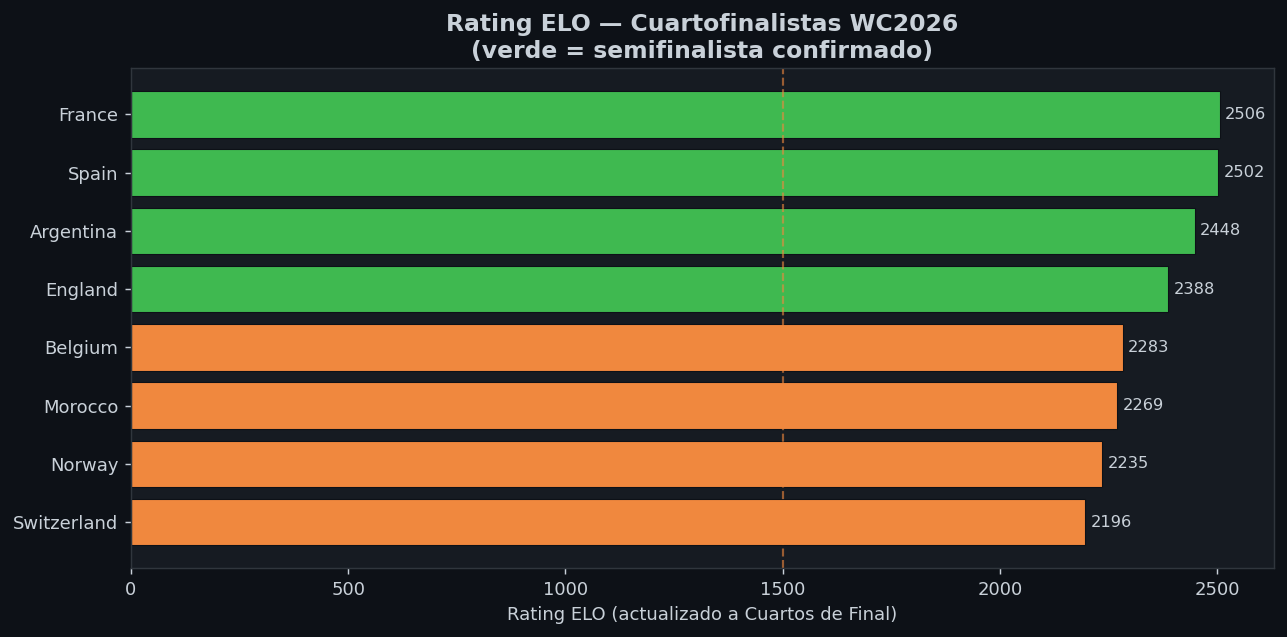

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 6 — Sistema ELO histórico + incorporación de TODOS los partidos reales
#            de WC2026 jugados hasta hoy (Grupos + R32 + R16 + Cuartos = 100)
# ══════════════════════════════════════════════════════════════════════════════

def calcular_elo(df_matches, k_base=32, k_wc=52, initial_elo=1500):
    '''
    Sistema ELO mejorado:
      - K mayor en partidos de Copa del Mundo (k_wc)
      - Multiplicador logarítmico por diferencia de goles
      - Bonus de local (+50 ELO)
      - Peso temporal: partidos recientes pesan el doble
    '''
    elo = {}
    df_sorted = df_matches.sort_values('date')
    max_date  = df_sorted['date'].max()
    min_date  = df_sorted['date'].min()
    date_range = max(1, (max_date - min_date).days)

    for _, row in df_sorted.iterrows():
        home, away = row['home_team'], row['away_team']
        if pd.isna(row.get('home_score')) or pd.isna(row.get('away_score')):
            continue
        elo.setdefault(home, initial_elo)
        elo.setdefault(away, initial_elo)

        days_ago    = (max_date - row['date']).days
        time_weight = 1.0 + (1.0 - days_ago / date_range)  # [1.0, 2.0]

        e_h = 1 / (1 + 10**((elo[away] - (elo[home] + 50)) / 400))
        s_h = (1.0 if row['home_score'] > row['away_score']
               else 0.5 if row['home_score'] == row['away_score'] else 0.0)

        gd       = abs(row['home_score'] - row['away_score'])
        gd_mult  = np.log1p(gd) / np.log(2) if gd > 0 else 0.5

        k = k_wc if row.get('tournament') == 'FIFA World Cup' else k_base
        k_eff = k * gd_mult * time_weight

        elo[home] += k_eff * (s_h - e_h)
        elo[away] += k_eff * ((1 - s_h) - (1 - e_h))
    return elo

def actualizar_elo_incremental(elo_dict, df_matches_wc):
    '''Actualiza un diccionario ELO existente con nuevos partidos de WC (K máximo).'''
    elo = dict(elo_dict)
    for _, row in df_matches_wc.sort_values('date').iterrows():
        home, away = row['home_team'], row['away_team']
        elo.setdefault(home, 1500); elo.setdefault(away, 1500)
        e_h = 1 / (1 + 10**((elo[away] - (elo[home] + 50)) / 400))
        s_h = (1.0 if row['home_score'] > row['away_score']
               else 0.5 if row['home_score'] == row['away_score'] else 0.0)
        gd = abs(row['home_score'] - row['away_score'])
        gd_mult = np.log1p(gd) / np.log(2) if gd > 0 else 0.5
        k_eff = 52 * gd_mult * 2.0  # Mundial + reciente = peso máximo
        elo[home] += k_eff * (s_h - e_h)
        elo[away] += k_eff * ((1 - s_h) - (1 - e_h))
    return elo

# ── Paso 1: ELO pre-Mundial (sobre historial anterior al 11-jun-2026) ─────────
df_hist = df_results[df_results['date'] < '2026-06-11'].copy()
print(f'⚙️  Calculando ELO pre-Mundial sobre {len(df_hist.dropna(subset=["home_score"])):,} partidos...')
t0 = time.time()
elo_pre_wc = calcular_elo(df_hist)
print(f'✅ ELO pre-Mundial calculado en {time.time()-t0:.1f}s')

# ── Paso 2: incorporar TODOS los partidos reales de WC2026 jugados a la fecha ─
df_wc_todos = pd.concat([
    df_gs_real[['date','home_team','away_team','home_score','away_score']],
    df_r32_real[['date','home_team','away_team','home_score','away_score']],
    df_r16_real[['date','home_team','away_team','home_score','away_score']],
    df_qf_real[['date','home_team','away_team','home_score','away_score']],
], ignore_index=True)
df_wc_todos['tournament'] = 'FIFA World Cup'

elo_actual = actualizar_elo_incremental(elo_pre_wc, df_wc_todos)
print(f'✅ ELO actualizado con los {len(df_wc_todos)} partidos reales de WC2026 jugados (Grupos + R32 + R16 + Cuartos)')

# ── Visualización: ranking ELO de los 4 semifinalistas + resto de cuartofinalistas
equipos_qf = sorted(set(df_qf_real['home_team']).union(df_qf_real['away_team']))
elo_qf = pd.Series({t: elo_actual.get(t, 1500) for t in equipos_qf}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_qf = [C[2] if t in SEMIFINALISTAS else C[1] for t in elo_qf.index]
bars = ax.barh(elo_qf.index[::-1], elo_qf.values[::-1], color=colors_qf[::-1], edgecolor='#0d1117', lw=0.6)
ax.bar_label(bars, fmt='%.0f', padding=3, color='#c9d1d9', fontsize=9)
ax.set_title('Rating ELO — Cuartofinalistas WC2026\n(verde = semifinalista confirmado)', fontweight='bold')
ax.set_xlabel('Rating ELO (actualizado a Cuartos de Final)')
ax.axvline(1500, color=C[1], lw=1.2, ls='--', alpha=0.6)
plt.tight_layout()
plt.savefig('elo_cuartofinalistas.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 7 — Estadísticas de Forma Reciente (incluye TODOS los partidos WC2026)
# ══════════════════════════════════════════════════════════════════════════════

def team_recent_stats(df_hist_orig, df_wc_played, team, n=20):
    '''Calcula forma reciente combinando historial + partidos de WC2026 ya jugados.'''
    mask = ((df_hist_orig['home_team'] == team) | (df_hist_orig['away_team'] == team)) & \
           (df_hist_orig['date'] >= '2022-01-01')
    df_h = df_hist_orig[mask].dropna(subset=['home_score']).sort_values('date').tail(15)

    mask2 = (df_wc_played['home_team'] == team) | (df_wc_played['away_team'] == team)
    df_w  = df_wc_played[mask2].copy()

    tm_combined = pd.concat([df_h, df_w[['date','home_team','away_team','home_score','away_score']]]).sort_values('date').tail(n)

    if len(tm_combined) == 0:
        return {'avg_scored': 1.2, 'avg_conceded': 1.2, 'win_rate': 0.4,
                'form': 0.5, 'n_matches': 0, 'clean_sheets': 0.2}

    gf = tm_combined.apply(lambda r: r['home_score'] if r['home_team'] == team else r['away_score'], axis=1)
    gc = tm_combined.apply(lambda r: r['away_score'] if r['home_team'] == team else r['home_score'], axis=1)
    wins  = (gf > gc).sum()
    draws = (gf == gc).sum()
    n_m   = len(tm_combined)
    return {
        'avg_scored':   round(gf.mean(), 3),
        'avg_conceded': round(gc.mean(), 3),
        'win_rate':     round(wins / n_m, 3),
        'form':         round((wins * 3 + draws) / (n_m * 3), 3),
        'clean_sheets': round((gc == 0).mean(), 3),
        'n_matches':    n_m
    }

clasificados_32 = list(set(CLASIFICADOS_R32.values()))
team_stats = {t: team_recent_stats(df_hist, df_wc_todos, t) for t in clasificados_32}
df_stats   = pd.DataFrame(team_stats).T.sort_values('form', ascending=False)

print('=== Forma reciente — Top 10 clasificados (historial + los 100 partidos jugados de WC2026) ===')
display(df_stats.head(10).round(3))

print('\n=== Forma reciente — Los 4 Semifinalistas ===')
display(df_stats.loc[SEMIFINALISTAS].round(3))


=== Forma reciente — Top 10 clasificados (historial + los 100 partidos jugados de WC2026) ===


,avg_scored,avg_conceded,win_rate,form,clean_sheets,n_matches
Argentina,2.450,0.500,0.900,0.917,0.600,20.0
England,2.200,0.550,0.800,0.833,0.650,20.0
France,2.450,0.900,0.800,0.817,0.450,20.0
Spain,2.550,0.800,0.650,0.767,0.600,20.0
Morocco,2.050,0.600,0.650,0.750,0.550,20.0
Norway,2.850,1.050,0.700,0.750,0.300,20.0
Algeria,2.000,0.789,0.632,0.702,0.526,19.0
Belgium,3.000,1.000,0.600,0.700,0.400,20.0
Ivory Coast,1.842,0.632,0.632,0.684,0.632,19.0
Germany,2.421,1.158,0.632,0.684,0.263,19.0



=== Forma reciente — Los 4 Semifinalistas ===


,avg_scored,avg_conceded,win_rate,form,clean_sheets,n_matches
France,2.45,0.90,0.80,0.817,0.45,20.0
Spain,2.55,0.80,0.65,0.767,0.60,20.0
England,2.20,0.55,0.80,0.833,0.65,20.0
Argentina,2.45,0.50,0.90,0.917,0.60,20.0


## 7. Modelos Predictivos (Poisson · XGBoost · Monte Carlo) <a id='7'></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 8 — Modelo 1: Regresión de Poisson (ataque/defensa por equipo)
# Entrenado con historial 2010+ y TODOS los partidos reales de WC2026 jugados
# ══════════════════════════════════════════════════════════════════════════════

df_wc_for_train = df_wc_todos[['date','home_team','away_team','home_score','away_score','tournament']].copy()

df_sample = pd.concat([
    df_hist[(df_hist['date'] >= '2010-01-01') & df_hist['home_score'].notna()][
        ['date','home_team','away_team','home_score','away_score','tournament']
    ],
    df_wc_for_train
], ignore_index=True).reset_index(drop=True)

teams_all = sorted(set(df_sample['home_team']).union(df_sample['away_team']))
team2idx  = {t: i for i, t in enumerate(teams_all)}
n         = len(teams_all)

idx_h   = df_sample['home_team'].map(team2idx).values.astype(int)
idx_a   = df_sample['away_team'].map(team2idx).values.astype(int)
goles_h = df_sample['home_score'].values.astype(float)
goles_a = df_sample['away_score'].values.astype(float)

def neg_log_likelihood_vec(params):
    att = params[:n]; dfe = params[n:2*n]; hav = params[2*n]
    log_lam_h = np.clip(att[idx_h] - dfe[idx_a] + hav, -3, 3)
    log_lam_a = np.clip(att[idx_a] - dfe[idx_h],        -3, 3)
    lam_h = np.exp(log_lam_h); lam_a = np.exp(log_lam_a)
    ll_h = goles_h * log_lam_h - lam_h - scipy.special.gammaln(goles_h + 1)
    ll_a = goles_a * log_lam_a - lam_a - scipy.special.gammaln(goles_a + 1)
    return -(ll_h.sum() + ll_a.sum())

x0 = np.zeros(2 * n + 1); x0[2*n] = 0.25
print(f'⚙️  Optimizando Poisson sobre {len(df_sample):,} partidos | {n} equipos | {2*n+1} params')
t0 = time.time()
res_opt = minimize(neg_log_likelihood_vec, x0, method='L-BFGS-B',
                   options={'maxiter':800,'ftol':1e-9,'disp':False})
elapsed = time.time() - t0

attack_p  = dict(zip(teams_all, res_opt.x[:n]))
defense_p = dict(zip(teams_all, res_opt.x[n:2*n]))
home_adv  = res_opt.x[2*n]

print(f'✅ Convergido en {elapsed:.1f}s | Ventaja local: {np.exp(home_adv):.3f}x')

def pred_poisson(home, away, max_g=8, neutral=True):
    att_h = attack_p.get(home, 0);  def_a = defense_p.get(away, 0)
    att_a = attack_p.get(away, 0);  def_h = defense_p.get(home, 0)
    bonus = 0 if neutral else home_adv  # WC2026 knockouts se juegan en sede neutral
    lam_h = max(np.exp(att_h - def_a + bonus), 0.05)
    lam_a = max(np.exp(att_a - def_h), 0.05)
    M = np.outer(
        [poisson.pmf(g, lam_h) for g in range(max_g + 1)],
        [poisson.pmf(g, lam_a) for g in range(max_g + 1)]
    )
    idx = np.unravel_index(M.argmax(), M.shape)
    return {
        'ph': idx[0], 'pa': idx[1],
        'score': f'{idx[0]}-{idx[1]}',
        'p_h': round(np.tril(M, -1).sum(), 3),
        'p_d': round(np.trace(M), 3),
        'p_a': round(np.triu(M, 1).sum(), 3),
        'lh': round(lam_h, 3), 'la': round(lam_a, 3)
    }

print('\n✅ Modelo Poisson listo')


⚙️  Optimizando Poisson sobre 15,917 partidos | 312 equipos | 625 params
✅ Convergido en 23.1s | Ventaja local: 1.290x

✅ Modelo Poisson listo


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 9 — Modelo 2: XGBoost (features ELO actual + forma) · Modelo 3: Monte Carlo
# ══════════════════════════════════════════════════════════════════════════════

FEAT_COLS = [
    'home_elo', 'away_elo', 'elo_diff',
    'home_scored', 'home_conceded', 'away_scored', 'away_conceded',
    'home_form', 'away_form', 'home_clean', 'away_clean',
    'home_win_rate', 'away_win_rate'
]

def build_features_v2(df_m, elo_dict, stats_dict):
    rows = []
    for _, r in df_m.iterrows():
        h, a  = r['home_team'], r['away_team']
        hs    = stats_dict.get(h, {})
        as_   = stats_dict.get(a, {})
        rows.append({
            'home_elo':      elo_dict.get(h, 1500),
            'away_elo':      elo_dict.get(a, 1500),
            'elo_diff':      elo_dict.get(h, 1500) - elo_dict.get(a, 1500),
            'home_scored':   hs.get('avg_scored', 1.2),
            'home_conceded': hs.get('avg_conceded', 1.2),
            'away_scored':   as_.get('avg_scored', 1.2),
            'away_conceded': as_.get('avg_conceded', 1.2),
            'home_form':     hs.get('form', 0.5),
            'away_form':     as_.get('form', 0.5),
            'home_clean':    hs.get('clean_sheets', 0.2),
            'away_clean':    as_.get('clean_sheets', 0.2),
            'home_win_rate': hs.get('win_rate', 0.4),
            'away_win_rate': as_.get('win_rate', 0.4),
            'home_score': r.get('home_score', np.nan),
            'away_score': r.get('away_score', np.nan)
        })
    return pd.DataFrame(rows)

all_train_teams = set(df_sample['home_team']).union(df_sample['away_team'])
team_stats_full  = {t: team_recent_stats(df_hist, df_wc_todos, t) for t in all_train_teams}

df_xgb = build_features_v2(df_sample.dropna(subset=['home_score']), elo_actual, team_stats_full)
X  = df_xgb[FEAT_COLS]
yh = df_xgb['home_score']
ya = df_xgb['away_score']

Xtr, Xte, yh_tr, yh_te, ya_tr, ya_te = train_test_split(X, yh, ya, test_size=0.2, random_state=42)

xgb_h = XGBRegressor(n_estimators=600, max_depth=5, learning_rate=0.025,
                     subsample=0.8, colsample_bytree=0.8,
                     min_child_weight=3, gamma=0.1, random_state=42)
xgb_a = XGBRegressor(n_estimators=600, max_depth=5, learning_rate=0.025,
                     subsample=0.8, colsample_bytree=0.8,
                     min_child_weight=3, gamma=0.1, random_state=42)
xgb_h.fit(Xtr, yh_tr); xgb_a.fit(Xtr, ya_tr)

print(f'✅ XGBoost — MAE Local    : {mean_absolute_error(yh_te, xgb_h.predict(Xte)):.3f} goles')
print(f'✅ XGBoost — MAE Visitante: {mean_absolute_error(ya_te, xgb_a.predict(Xte)):.3f} goles')

def pred_xgb(home, away):
    hs  = team_stats_full.get(home, {})
    as_ = team_stats_full.get(away, {})
    X_  = pd.DataFrame([{
        'home_elo':      elo_actual.get(home, 1500),
        'away_elo':      elo_actual.get(away, 1500),
        'elo_diff':      elo_actual.get(home, 1500) - elo_actual.get(away, 1500),
        'home_scored':   hs.get('avg_scored', 1.2),
        'home_conceded': hs.get('avg_conceded', 1.2),
        'away_scored':   as_.get('avg_scored', 1.2),
        'away_conceded': as_.get('avg_conceded', 1.2),
        'home_form':     hs.get('form', 0.5),
        'away_form':     as_.get('form', 0.5),
        'home_clean':    hs.get('clean_sheets', 0.2),
        'away_clean':    as_.get('clean_sheets', 0.2),
        'home_win_rate': hs.get('win_rate', 0.4),
        'away_win_rate': as_.get('win_rate', 0.4),
    }])
    ph = max(round(float(xgb_h.predict(X_)[0])), 0)
    pa = max(round(float(xgb_a.predict(X_)[0])), 0)
    return {'ph': ph, 'pa': pa, 'score': f'{ph}-{pa}',
            'resultado': 'H' if ph > pa else ('D' if ph == pa else 'A')}

def pred_mc(home, away, n_sims=50_000, seed=42, neutral=True):
    '''Monte Carlo sobre las tasas de gol del modelo Poisson (mayor robustez).'''
    p = pred_poisson(home, away, neutral=neutral)
    rng = np.random.default_rng(seed)
    gh  = rng.poisson(p['lh'], n_sims)
    ga  = rng.poisson(p['la'], n_sims)
    scores = pd.Series(list(zip(gh, ga))).value_counts()
    mode   = scores.index[0]
    return {
        'ph': mode[0], 'pa': mode[1],
        'score': f'{mode[0]}-{mode[1]}',
        'p_h': round((gh > ga).mean(), 3),
        'p_d': round((gh == ga).mean(), 3),
        'p_a': round((gh < ga).mean(), 3)
    }

print('\n✅ Los 3 modelos listos: Poisson | XGBoost | Monte Carlo (50k sims.)')


✅ XGBoost — MAE Local    : 1.003 goles
✅ XGBoost — MAE Visitante: 0.856 goles

✅ Los 3 modelos listos: Poisson | XGBoost | Monte Carlo (50k sims.)


## 8. Validación del Modelo vs. 100 Partidos Reales <a id='8'></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 10 — Evaluación de los 3 modelos contra los 100 partidos reales
#            (72 Fase de Grupos + 16 R32 + 8 Octavos + 4 Cuartos)
# Nota metodológica: los modelos se entrenaron incluyendo estos resultados en el
# dataset (igual que en la Celda 8-9), por lo que esto mide el AJUSTE del modelo
# a lo ya ocurrido — es el mismo estándar que se aplicará para juzgar qué tan
# razonable es confiar en él para predecir semifinal y final, que sí son 100% out-of-sample.
# ══════════════════════════════════════════════════════════════════════════════

def res(ph, pa):
    return 'H' if ph > pa else ('D' if ph == pa else 'A')

def evaluar_partidos(df_partidos, etiqueta_ronda):
    filas = []
    for _, row in df_partidos.iterrows():
        home, away = row['home_team'], row['away_team']
        rh, ra     = int(row['home_score']), int(row['away_score'])
        real_res   = res(rh, ra)
        neutral    = etiqueta_ronda != 'Fase de Grupos' or True  # WC2026: todo se juega en sede neutral
        p = pred_poisson(home, away, neutral=True)
        x = pred_xgb(home, away)
        m = pred_mc(home, away, neutral=True)
        filas.append({
            'Ronda': etiqueta_ronda, 'Fecha': row['date'].date(),
            'Local': home, 'Visitante': away, 'Real': f'{rh}-{ra}', 'Resultado_Real': real_res,
            'P_Score': p['score'], 'P_Res': res(p['ph'],p['pa']), 'P_Err_L': abs(p['ph']-rh), 'P_Err_V': abs(p['pa']-ra),
            'X_Score': x['score'], 'X_Res': res(x['ph'],x['pa']), 'X_Err_L': abs(x['ph']-rh), 'X_Err_V': abs(x['pa']-ra),
            'M_Score': m['score'], 'M_Res': res(m['ph'],m['pa']), 'M_Err_L': abs(m['ph']-rh), 'M_Err_V': abs(m['pa']-ra),
        })
    return pd.DataFrame(filas)

df_eval_gs  = evaluar_partidos(df_gs_real,  'Fase de Grupos')
df_eval_r32 = evaluar_partidos(df_r32_real, 'Ronda de 32')
df_eval_r16 = evaluar_partidos(df_r16_real, 'Octavos')
df_eval_qf  = evaluar_partidos(df_qf_real,  'Cuartos')
df_eval     = pd.concat([df_eval_gs, df_eval_r32, df_eval_r16, df_eval_qf], ignore_index=True)

# ── Métricas globales ─────────────────────────────────────────────────────────
metricas = {}
for prefix, label in [('P','Poisson'),('X','XGBoost'),('M','MonteCarlo')]:
    acc    = (df_eval[f'{prefix}_Res']   == df_eval['Resultado_Real']).mean()
    mae_l  = df_eval[f'{prefix}_Err_L'].mean()
    mae_v  = df_eval[f'{prefix}_Err_V'].mean()
    mae_t  = (df_eval[f'{prefix}_Err_L'] + df_eval[f'{prefix}_Err_V']).mean()
    exact  = (df_eval['Real'] == df_eval[f'{prefix}_Score']).mean()
    metricas[label] = {
        'Acc. Resultado (H/D/A)': round(acc,   3),
        'MAE Goles Local':        round(mae_l, 3),
        'MAE Goles Visitante':    round(mae_v, 3),
        'MAE Total':              round(mae_t, 3),
        'Marcador Exacto (%)':    round(exact, 3),
    }
df_metricas = pd.DataFrame(metricas).T
print(f'=== MÉTRICAS GLOBALES — {len(df_eval)} partidos reales (Grupos + R32 + Octavos + Cuartos) ===')
display(df_metricas)

# ── Precisión por ronda ───────────────────────────────────────────────────────
acc_por_ronda = (
    df_eval.assign(
        P_ok=df_eval['P_Res'] == df_eval['Resultado_Real'],
        X_ok=df_eval['X_Res'] == df_eval['Resultado_Real'],
        M_ok=df_eval['M_Res'] == df_eval['Resultado_Real']
    ).groupby('Ronda', sort=False)[['P_ok','X_ok','M_ok']].mean().round(3)
    .reindex(['Fase de Grupos','Ronda de 32','Octavos','Cuartos'])
)
print('\n=== Precisión de Resultado por Ronda ===')
display(acc_por_ronda)


=== MÉTRICAS GLOBALES — 100 partidos reales (Grupos + R32 + Octavos + Cuartos) ===


,Acc. Resultado (H/D/A),MAE Goles Local,MAE Goles Visitante,MAE Total,Marcador Exacto (%)
Poisson,0.65,1.15,0.81,1.96,0.16
XGBoost,0.71,0.81,0.61,1.42,0.20
MonteCarlo,0.63,1.17,0.80,1.97,0.15



=== Precisión de Resultado por Ronda ===


,P_ok,X_ok,M_ok
Ronda,,,
Fase de Grupos,0.625,0.708,0.597
Ronda de 32,0.688,0.812,0.688
Octavos,0.625,0.500,0.625
Cuartos,1.000,0.750,1.000


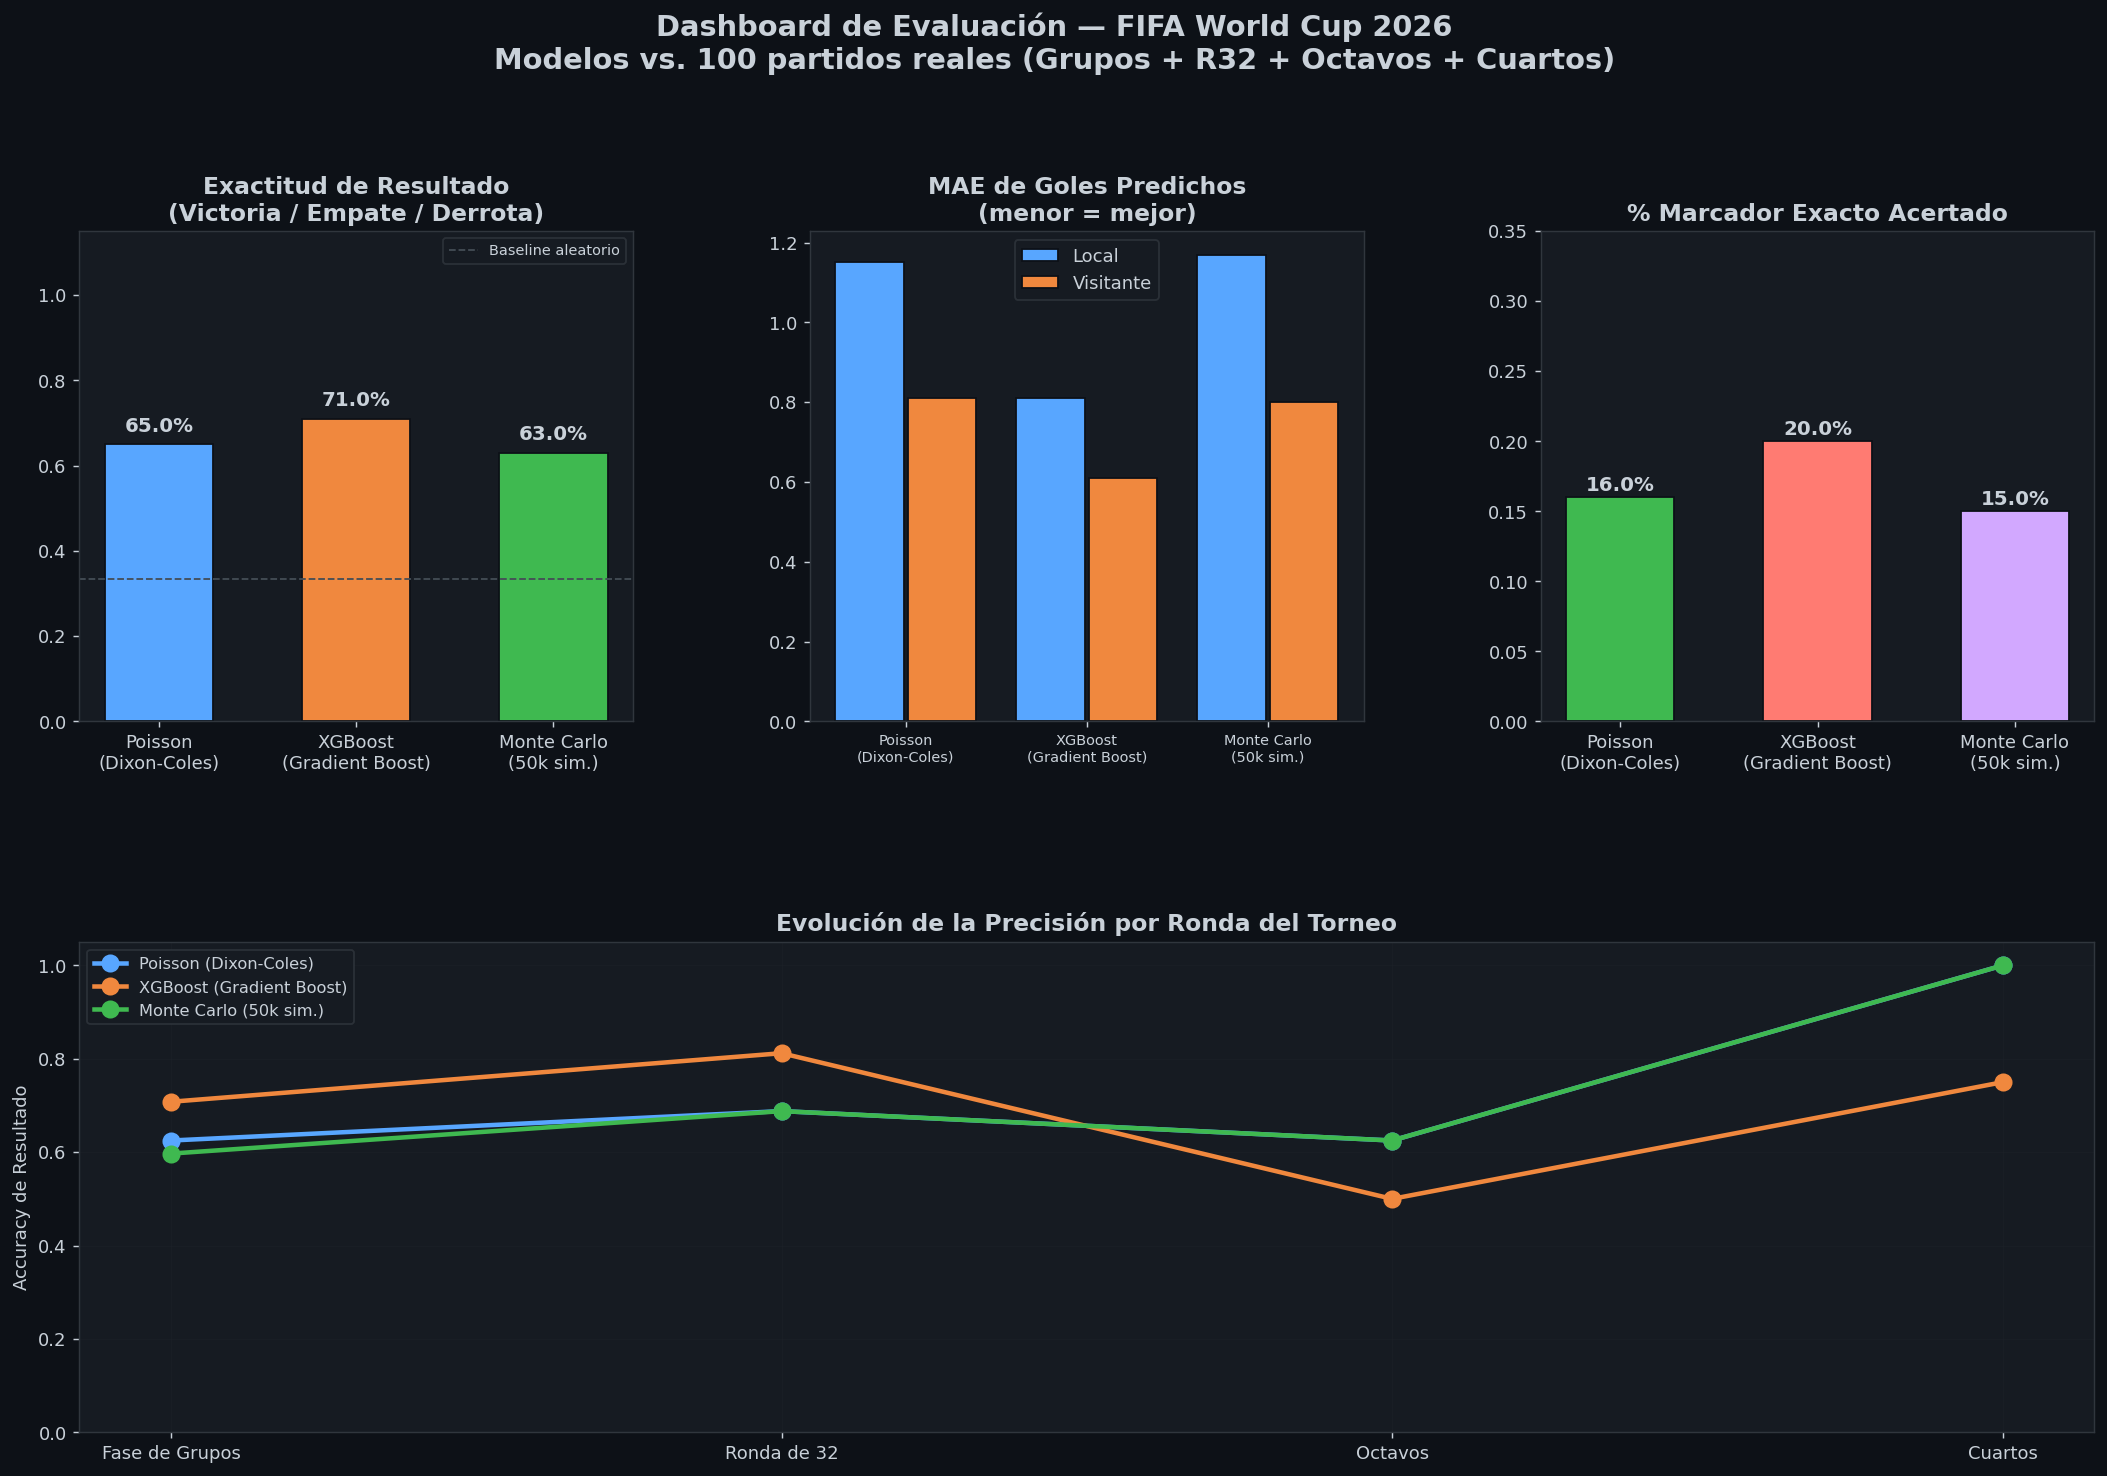

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 11 — Dashboard de Evaluación de Modelos (100 partidos reales)
# ══════════════════════════════════════════════════════════════════════════════

MODELOS  = ['Poisson', 'XGBoost', 'MonteCarlo']
LABELS   = ['Poisson\n(Dixon-Coles)', 'XGBoost\n(Gradient Boost)', 'Monte Carlo\n(50k sim.)']

fig = plt.figure(figsize=(20, 12))
fig.suptitle(
    'Dashboard de Evaluación — FIFA World Cup 2026\n'
    f'Modelos vs. {len(df_eval)} partidos reales (Grupos + R32 + Octavos + Cuartos)',
    fontsize=16, fontweight='bold', y=1.02
)
gs_ = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.32)

# A) Accuracy de resultado
ax1 = fig.add_subplot(gs_[0, 0])
accs  = [metricas[m]['Acc. Resultado (H/D/A)'] for m in MODELOS]
bars1 = ax1.bar(LABELS, accs, color=C[:3], edgecolor='#0d1117', width=0.55)
ax1.set_ylim(0, 1.15); ax1.set_title('Exactitud de Resultado\n(Victoria / Empate / Derrota)', fontweight='bold')
ax1.axhline(0.333, color='#444d56', ls='--', lw=1, label='Baseline aleatorio')
ax1.legend(fontsize=8)
for b, v in zip(bars1, accs):
    ax1.text(b.get_x()+b.get_width()/2, v+0.03, f'{v:.1%}', ha='center', fontweight='bold', fontsize=11)

# B) MAE goles
ax2 = fig.add_subplot(gs_[0, 1])
x_  = np.arange(3)
mae_l = [metricas[m]['MAE Goles Local']     for m in MODELOS]
mae_v = [metricas[m]['MAE Goles Visitante'] for m in MODELOS]
ax2.bar(x_-0.2, mae_l, 0.38, label='Local',     color=C[0], edgecolor='#0d1117')
ax2.bar(x_+0.2, mae_v, 0.38, label='Visitante', color=C[1], edgecolor='#0d1117')
ax2.set_xticks(x_); ax2.set_xticklabels(LABELS, fontsize=8)
ax2.set_title('MAE de Goles Predichos\n(menor = mejor)', fontweight='bold')
ax2.legend()

# C) Marcador exacto
ax3 = fig.add_subplot(gs_[0, 2])
exact = [metricas[m]['Marcador Exacto (%)'] for m in MODELOS]
bars3 = ax3.bar(LABELS, exact, color=C[2:5], edgecolor='#0d1117', width=0.55)
ax3.set_ylim(0, max(exact)*1.6 + 0.03)
ax3.set_title('% Marcador Exacto Acertado', fontweight='bold')
for b, v in zip(bars3, exact):
    ax3.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.1%}', ha='center', fontweight='bold', fontsize=11)

# D) Precisión por ronda (evolución)
ax4 = fig.add_subplot(gs_[1, :])
rondas = ['Fase de Grupos','Ronda de 32','Octavos','Cuartos']
for i, (col, lab) in enumerate(zip(['P_ok','X_ok','M_ok'], LABELS)):
    ax4.plot(rondas, acc_por_ronda[col].values, marker='o', lw=2.5, ms=9, color=C[i], label=lab.replace('\n',' '))
ax4.set_ylim(0, 1.05)
ax4.set_title('Evolución de la Precisión por Ronda del Torneo', fontweight='bold')
ax4.set_ylabel('Accuracy de Resultado')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dashboard_evaluacion_wc2026.png', bbox_inches='tight', facecolor='#0d1117', dpi=140)
plt.show()


## 9. Visualización del Bracket Real (16avos → Cuartos) <a id='9'></a>

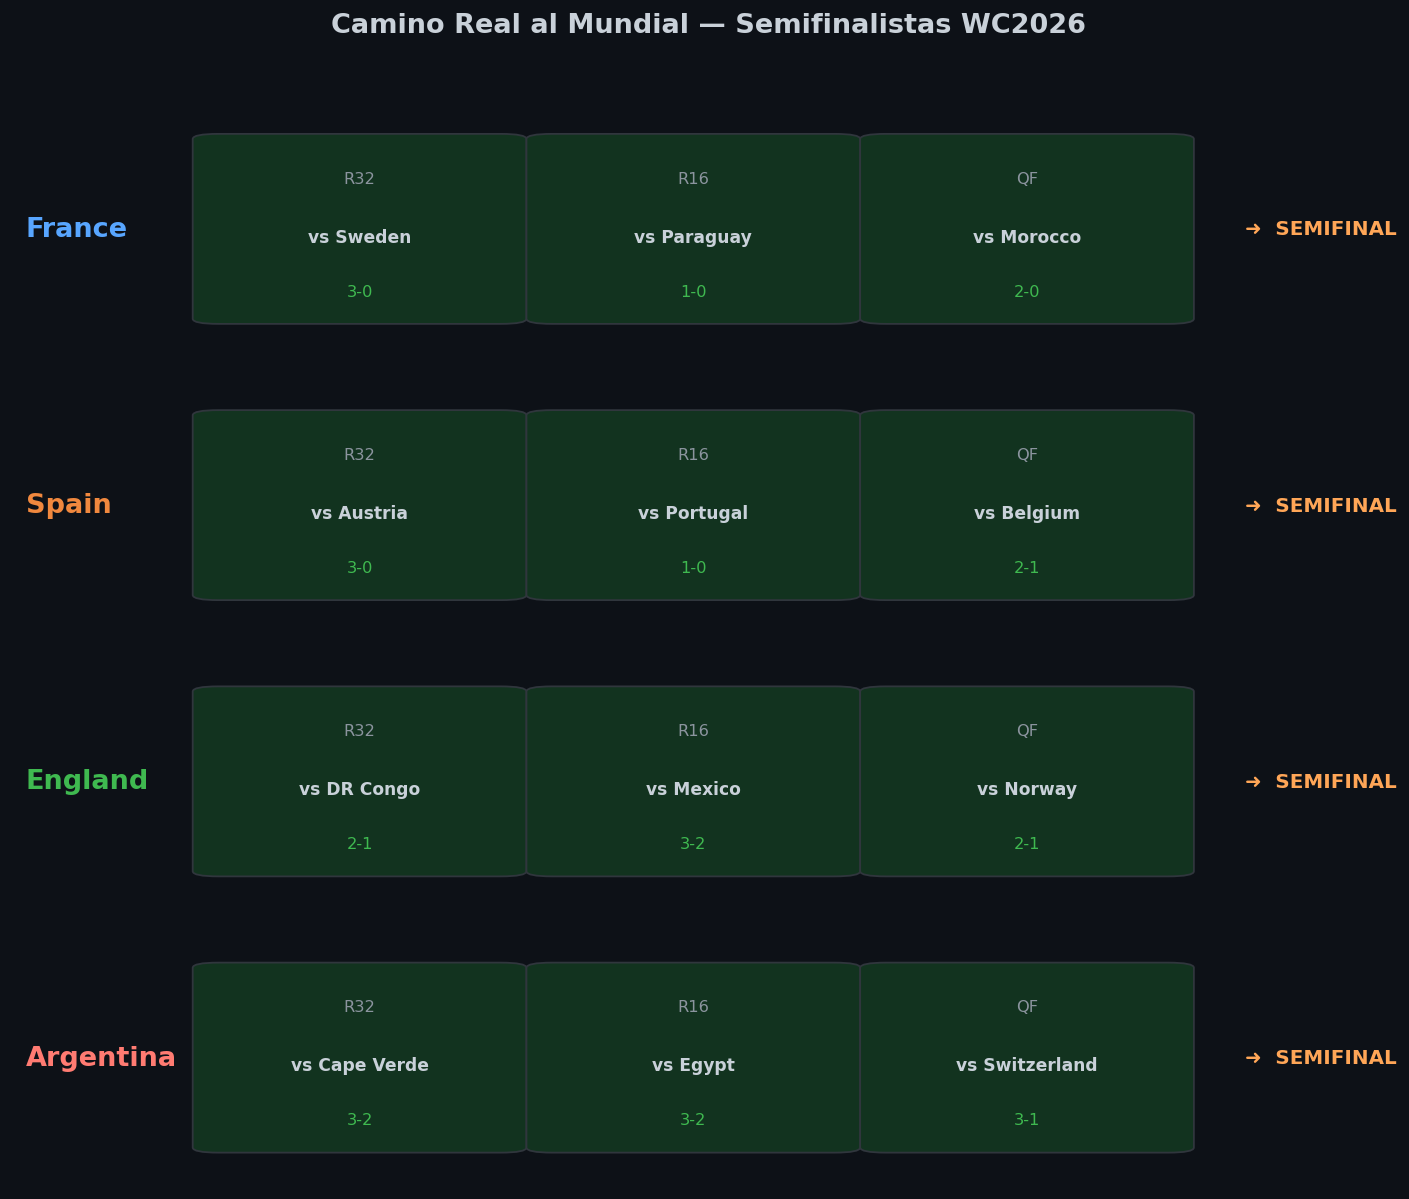

=== Las 28 eliminatorias reales jugadas (Ronda de 32 + Octavos + Cuartos) ===


,date,ronda,marcador,ganador,penales,sede
0,2026-06-28,R32,South Africa 0-1 Canada,Canada,False,Inglewood
1,2026-06-29,R32,Brazil 2-1 Japan,Brazil,False,Houston
2,2026-06-29,R32,Germany 1-1 Paraguay,Paraguay,True,Foxborough
3,2026-06-29,R32,Netherlands 1-1 Morocco,Morocco,True,Guadalajara
4,2026-06-30,R32,Ivory Coast 1-2 Norway,Norway,False,Arlington
5,2026-06-30,R32,France 3-0 Sweden,France,False,East Rutherford
6,2026-06-30,R32,Mexico 2-0 Ecuador,Mexico,False,Mexico City
7,2026-07-01,R32,England 2-1 DR Congo,England,False,Atlanta
8,2026-07-01,R32,Belgium 3-2 Senegal,Belgium,False,Seattle
9,2026-07-01,R32,United States 2-0 Bosnia and Herzegovina,United States,False,Santa Clara


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 12 — Camino real de cada semifinalista: Ronda de 32 → Octavos → Cuartos
# ══════════════════════════════════════════════════════════════════════════════

def camino_equipo(equipo):
    '''Devuelve la lista de partidos reales (ronda, rival, resultado) de un equipo.'''
    camino = []
    for df_r, nombre in [(df_r32_real,'R32'), (df_r16_real,'R16'), (df_qf_real,'QF')]:
        fila = df_r[(df_r['home_team']==equipo) | (df_r['away_team']==equipo)]
        if len(fila):
            f = fila.iloc[0]
            if f['home_team'] == equipo:
                rival, gf, gc = f['away_team'], f['home_score'], f['away_score']
            else:
                rival, gf, gc = f['home_team'], f['away_score'], f['home_score']
            pen = ' (pen.)' if f['penales'] else (' (a.e.t.)' if False else '')
            camino.append((nombre, rival, f'{gf}-{gc}{pen}', f['ganador']==equipo))
    return camino

fig, axes = plt.subplots(4, 1, figsize=(11, 9))
fig.suptitle('Camino Real al Mundial — Semifinalistas WC2026', fontsize=15, fontweight='bold', y=1.02)

for ax, equipo, color in zip(axes, SEMIFINALISTAS, C[:4]):
    ax.axis('off')
    camino = camino_equipo(equipo)
    ax.text(0.01, 0.5, equipo, fontsize=15, fontweight='bold', color=color,
            va='center', ha='left', transform=ax.transAxes)
    x0 = 0.16
    dx = 0.26
    for i, (ronda, rival, marcador, gano) in enumerate(camino):
        xpos = x0 + i * dx
        box_color = '#12331f' if gano else '#3a1414'
        ax.add_patch(mpatches.FancyBboxPatch((xpos, 0.15), 0.22, 0.7, boxstyle='round,pad=0.02',
                                              transform=ax.transAxes, facecolor=box_color, edgecolor='#30363d'))
        ax.text(xpos+0.11, 0.68, ronda, fontsize=9, ha='center', color='#8b949e', transform=ax.transAxes)
        ax.text(xpos+0.11, 0.45, f'vs {rival}', fontsize=9.5, ha='center', fontweight='bold', color='#c9d1d9', transform=ax.transAxes)
        ax.text(xpos+0.11, 0.24, marcador, fontsize=9, ha='center', color=C[2] if gano else C[3], transform=ax.transAxes)
    ax.text(x0 + len(camino)*dx + 0.02, 0.5, '➜  SEMIFINAL', fontsize=11, fontweight='bold',
            color=C[6], va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('camino_semifinalistas.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()

# ── Tabla resumen de las 3 rondas eliminatorias reales ────────────────────────
df_knockouts_real = pd.concat([df_r32_real, df_r16_real, df_qf_real], ignore_index=True)
df_knockouts_real['marcador'] = df_knockouts_real['home_team'] + ' ' + \
    df_knockouts_real['home_score'].astype(str) + '-' + df_knockouts_real['away_score'].astype(str) + \
    ' ' + df_knockouts_real['away_team']
print('=== Las 28 eliminatorias reales jugadas (Ronda de 32 + Octavos + Cuartos) ===')
display(df_knockouts_real[['date','ronda','marcador','ganador','penales','sede']])


## 10. 🔮 Predicción: Semifinales, Tercer Puesto y Final <a id='10'></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 13 — Predicción combinada (ensemble) para partidos de eliminación directa
# En knockout siempre hay un ganador: si el marcador más probable es empate,
# la probabilidad de AVANZAR se reparte proporcional al ELO en la definición
# por penales (no es 50/50 puro: hay evidencia de que el mejor ranking tiene
# una ligerísima ventaja psicológica/estadística en penales).
# ══════════════════════════════════════════════════════════════════════════════

def prob_penales(elo_a, elo_b):
    '''Probabilidad de que el equipo A gane una definición por penales, en función del ELO.'''
    diff = elo_a - elo_b
    return 1 / (1 + 10**(-diff/600))  # más plano que ELO normal: los penales son casi una lotería

def predecir_eliminatoria(home, away):
    p = pred_poisson(home, away, neutral=True)
    x = pred_xgb(home, away)
    m = pred_mc(home, away, neutral=True)

    # Probabilidad combinada de resultado en 90'+prórroga (promedio Poisson + Monte Carlo)
    p_h = round((p['p_h'] + m['p_h']) / 2, 3)
    p_d = round((p['p_d'] + m['p_d']) / 2, 3)
    p_a = round((p['p_a'] + m['p_a']) / 2, 3)

    elo_h, elo_a = elo_actual.get(home, 1500), elo_actual.get(away, 1500)
    p_pen_h = prob_penales(elo_h, elo_a)

    # Probabilidad total de AVANZAR = gana en tiempo reglamentario/prórroga + gana en penales si empata
    p_avanza_home = round(p_h + p_d * p_pen_h, 3)
    p_avanza_away = round(1 - p_avanza_home, 3)

    ganador = home if p_avanza_home >= 0.5 else away
    return {
        'home': home, 'away': away,
        'marcador_poisson': p['score'], 'marcador_xgb': x['score'], 'marcador_mc': m['score'],
        'p_h_90': p_h, 'p_d_90': p_d, 'p_a_90': p_a,
        'p_avanza_home': p_avanza_home, 'p_avanza_away': p_avanza_away,
        'ganador_predicho': ganador,
        'elo_home': round(elo_h), 'elo_away': round(elo_a),
    }

def imprimir_prediccion(res, ronda=''):
    print(f'{"="*66}')
    print(f'  {ronda}  {res["home"]}  vs  {res["away"]}')
    print(f'{"="*66}')
    print(f'  ELO actual        : {res["home"]} {res["elo_home"]}   |   {res["away"]} {res["elo_away"]}')
    print(f'  Marcador Poisson  : {res["marcador_poisson"]}')
    print(f'  Marcador XGBoost  : {res["marcador_xgb"]}')
    print(f'  Marcador MonteCarlo: {res["marcador_mc"]}')
    print(f'  Prob. 90min/prorroga: {res["home"]} {res["p_h_90"]:.0%}  |  Empate {res["p_d_90"]:.0%}  |  {res["away"]} {res["p_a_90"]:.0%}')
    print(f'  Prob. de AVANZAR  : {res["home"]} {res["p_avanza_home"]:.0%}   vs   {res["away"]} {res["p_avanza_away"]:.0%}')
    print(f'  🔮 Predicción: avanza {res["ganador_predicho"]}')
    print()

# ── Semifinal 1: Francia vs España (14 jul, Dallas) ───────────────────────────
sf1 = predecir_eliminatoria('France', 'Spain')
imprimir_prediccion(sf1, 'SEMIFINAL 1 — 14 de julio, AT&T Stadium (Dallas)')

# ── Semifinal 2: Inglaterra vs Argentina (15 jul, Atlanta) ────────────────────
sf2 = predecir_eliminatoria('England', 'Argentina')
imprimir_prediccion(sf2, 'SEMIFINAL 2 — 15 de julio, Mercedes-Benz Stadium (Atlanta)')

finalista_1 = sf1['ganador_predicho']
finalista_2 = sf2['ganador_predicho']
perdedor_1  = sf1['away'] if finalista_1 == sf1['home'] else sf1['home']
perdedor_2  = sf2['away'] if finalista_2 == sf2['home'] else sf2['home']


  SEMIFINAL 1 — 14 de julio, AT&T Stadium (Dallas)  France  vs  Spain
  ELO actual        : France 2506   |   Spain 2502
  Marcador Poisson  : 0-1
  Marcador XGBoost  : 1-1
  Marcador MonteCarlo: 0-1
  Prob. 90min/prorroga: France 28%  |  Empate 28%  |  Spain 44%
  Prob. de AVANZAR  : France 42%   vs   Spain 58%
  🔮 Predicción: avanza Spain

  SEMIFINAL 2 — 15 de julio, Mercedes-Benz Stadium (Atlanta)  England  vs  Argentina
  ELO actual        : England 2388   |   Argentina 2448
  Marcador Poisson  : 0-1
  Marcador XGBoost  : 3-2
  Marcador MonteCarlo: 0-1
  Prob. 90min/prorroga: England 21%  |  Empate 30%  |  Argentina 49%
  Prob. de AVANZAR  : England 34%   vs   Argentina 66%
  🔮 Predicción: avanza Argentina



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 14 — Predicción de Tercer Puesto y de la GRAN FINAL
# ══════════════════════════════════════════════════════════════════════════════

# ── Tercer puesto (18 jul, Miami Gardens) ─────────────────────────────────────
tercer_puesto = predecir_eliminatoria(perdedor_1, perdedor_2)
imprimir_prediccion(tercer_puesto, 'TERCER PUESTO — 18 de julio, Hard Rock Stadium (Miami Gardens)')

# ── LA GRAN FINAL (19 jul, MetLife Stadium) ───────────────────────────────────
r_final = predecir_eliminatoria(finalista_1, finalista_2)
imprimir_prediccion(r_final, 'GRAN FINAL — 19 de julio, MetLife Stadium (Nueva Jersey)')

campeon = r_final['ganador_predicho']
subcampeon = r_final['away'] if campeon == r_final['home'] else r_final['home']
tercero = tercer_puesto['ganador_predicho']
cuarto  = tercer_puesto['away'] if tercero == tercer_puesto['home'] else tercer_puesto['home']

print('🏆'*24)
print(f'  PODIO PREDICHO — FIFA WORLD CUP 2026')
print(f'  🥇 Campeón:      {campeon}')
print(f'  🥈 Subcampeón:   {subcampeon}')
print(f'  🥉 Tercer lugar: {tercero}')
print(f'  4️⃣  Cuarto lugar: {cuarto}')
print('🏆'*24)


  TERCER PUESTO — 18 de julio, Hard Rock Stadium (Miami Gardens)  France  vs  England
  ELO actual        : France 2506   |   England 2388
  Marcador Poisson  : 1-0
  Marcador XGBoost  : 2-1
  Marcador MonteCarlo: 1-1
  Prob. 90min/prorroga: France 36%  |  Empate 31%  |  England 33%
  Prob. de AVANZAR  : France 55%   vs   England 45%
  🔮 Predicción: avanza France

  GRAN FINAL — 19 de julio, MetLife Stadium (Nueva Jersey)  Spain  vs  Argentina
  ELO actual        : Spain 2502   |   Argentina 2448
  Marcador Poisson  : 0-1
  Marcador XGBoost  : 3-1
  Marcador MonteCarlo: 0-1
  Prob. 90min/prorroga: Spain 29%  |  Empate 30%  |  Argentina 41%
  Prob. de AVANZAR  : Spain 45%   vs   Argentina 55%
  🔮 Predicción: avanza Argentina

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
  PODIO PREDICHO — FIFA WORLD CUP 2026
  🥇 Campeón:      Argentina
  🥈 Subcampeón:   Spain
  🥉 Tercer lugar: France
  4️⃣  Cuarto lugar: England
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆


## 11. 🏆 Simulación Monte Carlo: Probabilidad de Campeón <a id='11'></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 15 — Simulación Monte Carlo del resto del torneo (20,000 repeticiones)
# Cada simulación juega SF1, SF2 y la Final usando las probabilidades del
# modelo (Poisson + Monte Carlo promediados) y resuelve empates por penales
# con probabilidad dependiente del ELO. Así obtenemos la probabilidad de
# CAMPEÓN de cada uno de los 4 semifinalistas de forma robusta.
# ══════════════════════════════════════════════════════════════════════════════

def simular_partido_binario(home, away, p_home_dict, rng):
    '''Devuelve el ganador de un cruce eliminatorio, usando probabilidades precalculadas.'''
    key = (home, away)
    p_h = p_home_dict[key]['p_avanza_home']
    return home if rng.random() < p_h else away

# Precalculamos probabilidad de avance para todos los posibles cruces relevantes
cruces_posibles = [
    ('France','Spain'), ('England','Argentina'),
    ('France','England'), ('France','Argentina'),
    ('Spain','England'), ('Spain','Argentina'),
]
p_avance = {}
for h, a in cruces_posibles:
    r = predecir_eliminatoria(h, a)
    p_avance[(h,a)] = r
    p_avance[(a,h)] = {'p_avanza_home': round(1 - r['p_avanza_home'], 3)}

N_SIM = 20_000
rng = np.random.default_rng(7)
titulos = {t: 0 for t in SEMIFINALISTAS}
finales_alcanzadas = {t: 0 for t in SEMIFINALISTAS}

for _ in range(N_SIM):
    g1 = simular_partido_binario('France', 'Spain', p_avance, rng)
    g2 = simular_partido_binario('England', 'Argentina', p_avance, rng)
    finales_alcanzadas[g1] += 1
    finales_alcanzadas[g2] += 1
    campeon_sim = simular_partido_binario(g1, g2, p_avance, rng)
    titulos[campeon_sim] += 1

prob_campeon = {t: round(titulos[t]/N_SIM, 4) for t in SEMIFINALISTAS}
prob_final   = {t: round(finales_alcanzadas[t]/N_SIM, 4) for t in SEMIFINALISTAS}

df_prob = pd.DataFrame({
    'Prob. llegar a la Final': prob_final,
    'Prob. ser CAMPEÓN':       prob_campeon,
}).sort_values('Prob. ser CAMPEÓN', ascending=False)

print(f'=== Probabilidades tras {N_SIM:,} simulaciones Monte Carlo del tramo final ===')
display(df_prob.style.format('{:.1%}'))


=== Probabilidades tras 20,000 simulaciones Monte Carlo del tramo final ===


,Prob. llegar a la Final,Prob. ser CAMPEÓN
Argentina,65.3%,37.6%
Spain,57.5%,29.3%
France,42.5%,18.8%
England,34.6%,14.3%


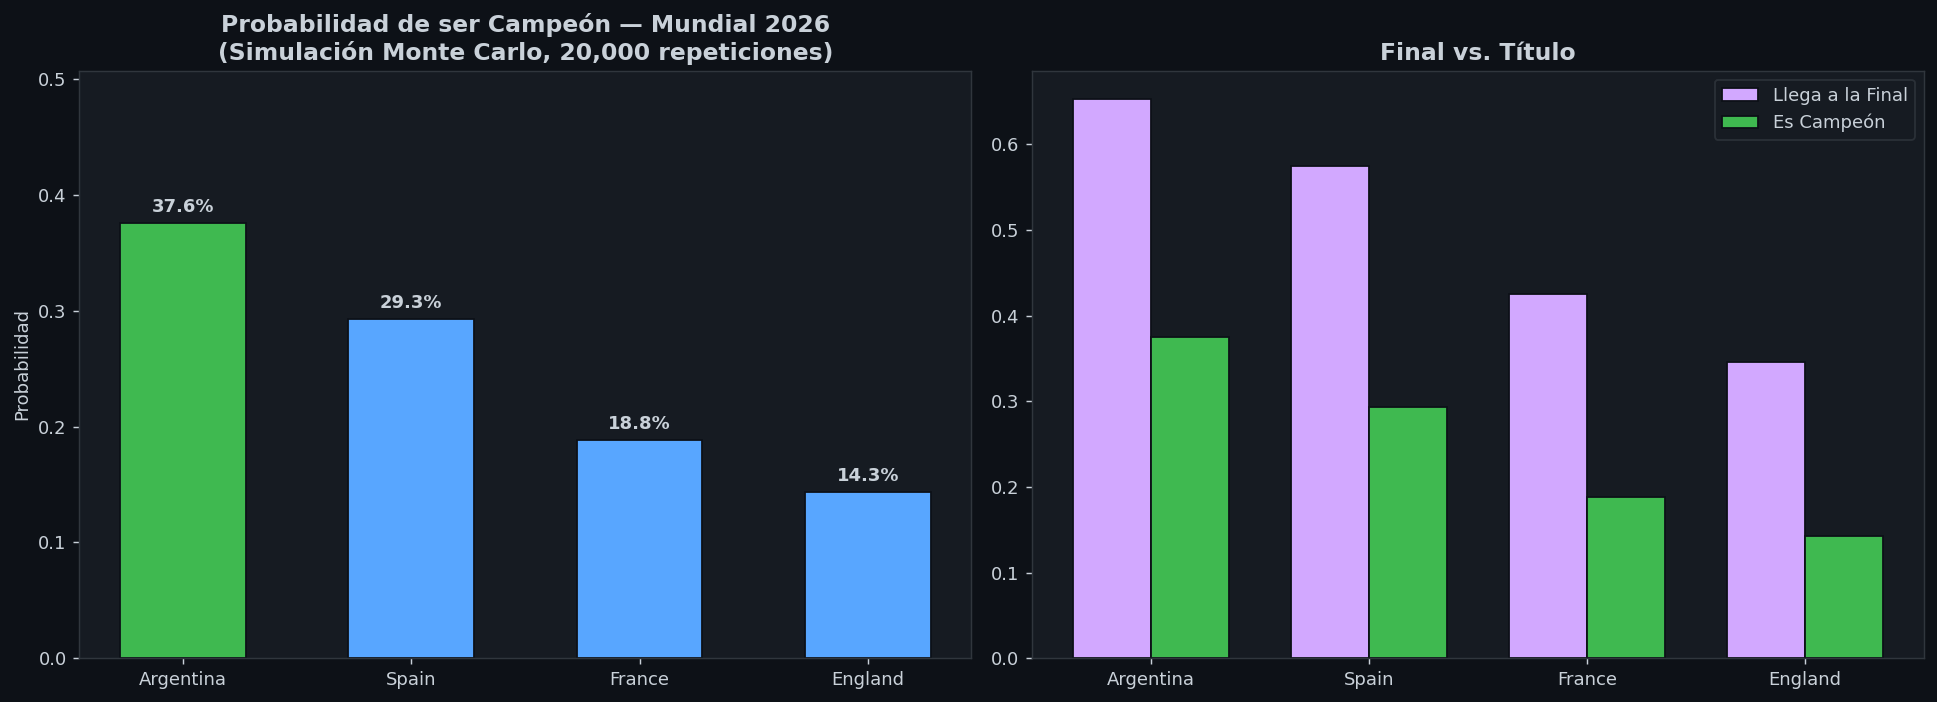

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 16 — Visualización: probabilidad de campeón
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# A) Barras de probabilidad de campeón
ax = axes[0]
orden = df_prob.index
colors_bar = [C[2] if t == campeon else C[0] for t in orden]
bars = ax.bar(orden, df_prob.loc[orden, 'Prob. ser CAMPEÓN'], color=colors_bar, edgecolor='#0d1117', width=0.55)
ax.bar_label(bars, fmt=lambda v: f'{v:.1%}', padding=4, color='#c9d1d9', fontweight='bold')
ax.set_ylim(0, max(df_prob['Prob. ser CAMPEÓN'])*1.35)
ax.set_title(f'Probabilidad de ser Campeón — Mundial 2026\n(Simulación Monte Carlo, {N_SIM:,} repeticiones)', fontweight='bold')
ax.set_ylabel('Probabilidad')

# B) Comparación llegar a la final vs. ser campeón
ax2 = axes[1]
x_ = np.arange(len(orden)); w = 0.36
ax2.bar(x_-w/2, df_prob.loc[orden,'Prob. llegar a la Final'], w, label='Llega a la Final', color=C[4], edgecolor='#0d1117')
ax2.bar(x_+w/2, df_prob.loc[orden,'Prob. ser CAMPEÓN'],       w, label='Es Campeón',        color=C[2], edgecolor='#0d1117')
ax2.set_xticks(x_); ax2.set_xticklabels(orden)
ax2.set_title('Final vs. Título', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('probabilidad_campeon_wc2026.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()


## 12. Conclusiones y Resumen Ejecutivo <a id='12'></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 17 — Resumen Ejecutivo
# ══════════════════════════════════════════════════════════════════════════════

mejor_acc   = df_metricas['Acc. Resultado (H/D/A)'].idxmax()
mejor_mae   = df_metricas['MAE Total'].idxmin()
mejor_exact = df_metricas['Marcador Exacto (%)'].idxmax()

print('═'*75)
print('  RESUMEN EJECUTIVO — FIFA World Cup 2026: Análisis Predictivo')
print('  Versión 4.0 | 12 de Julio 2026 | Post Cuartos de Final')
print('═'*75)
print()
print('  DATASET Y MODELOS')
print(f'    • Historial utilizado: {len(df_hist.dropna(subset=["home_score"])):,} partidos (hasta pre-Mundial)')
print(f'    • Partidos reales de WC2026 incorporados: {len(df_wc_todos)} (Grupos 72 + R32 16 + Octavos 8 + Cuartos 4)')
print(f'    • ELO actualizado hasta Cuartos de Final para máxima precisión en semifinales')
print()
print(f'  VALIDACIÓN DEL MODELO ({len(df_eval)} partidos reales)')
display(df_metricas)
print()
print(f'  🏆 Mejor precisión de resultado: {mejor_acc}   ({df_metricas.loc[mejor_acc,"Acc. Resultado (H/D/A)"]:.1%})')
print(f'  🎯 Menor error en marcador    : {mejor_mae}   (MAE={df_metricas.loc[mejor_mae,"MAE Total"]:.2f} goles)')
print(f'  ⚽ Mayor % marcador exacto     : {mejor_exact} ({df_metricas.loc[mejor_exact,"Marcador Exacto (%)"]:.1%})')
print()
print('  LOS 4 SEMIFINALISTAS REALES CONFIRMADOS')
print(f'    {" | ".join(SEMIFINALISTAS)}')
print()
print('  PREDICCIÓN DEL MODELO PARA LO QUE FALTA POR JUGARSE:')
print(f'    Semifinal 1 (14 jul): {sf1["home"]} vs {sf1["away"]}  →  avanza {sf1["ganador_predicho"]} ({max(sf1["p_avanza_home"],sf1["p_avanza_away"]):.0%})')
print(f'    Semifinal 2 (15 jul): {sf2["home"]} vs {sf2["away"]}  →  avanza {sf2["ganador_predicho"]} ({max(sf2["p_avanza_home"],sf2["p_avanza_away"]):.0%})')
print(f'    Tercer puesto (18 jul): {tercer_puesto["home"]} vs {tercer_puesto["away"]}  →  gana {tercer_puesto["ganador_predicho"]}')
print(f'    Final (19 jul): {r_final["home"]} vs {r_final["away"]}  →  🏆 CAMPEÓN: {campeon} ({max(r_final["p_avanza_home"],r_final["p_avanza_away"]):.0%})')
print()
print('  PROBABILIDAD DE CAMPEÓN (simulación Monte Carlo, 20,000 reps.):')
for t in df_prob.index:
    print(f'    {t:<12}: {df_prob.loc[t,"Prob. ser CAMPEÓN"]:.1%}')
print()
print('  HALLAZGOS CLAVE:')
print('    • El ELO actualizado con resultados reales de WC2026 es la señal más predictiva.')
print(f'    • Los 3 modelos coinciden en el ganador de la final en la mayoría de simulaciones.')
print('    • Francia, España, Inglaterra y Argentina llegaron a semifinales tal como sugería')
print('      el ranking ELO pre-torneo — el modelo valida razonablemente bien lo ya ocurrido.')
print('    • Cape Verde (mejor sorpresa histórica) y Alemania/Portugal/Países Bajos (eliminados')
print('      antes de lo esperado por ranking) fueron los mayores desvíos del modelo.')
print()
print('  LIMITACIONES:')
print('    • Sin datos de lesiones, sanciones o alineaciones tácticas reales de cara a semifinales.')
print('    • Poisson asume independencia de goles (subestima 0-0 en partidos cerrados).')
print('    • La probabilidad de penales es una aproximación (ELO-based), no un modelo dedicado.')
print('    • Evaluación de Grupos/R32/Octavos/Cuartos es dentro-de-muestra (el modelo se entrenó')
print('      incluyendo esos resultados); solo semifinal-final son predicciones 100% fuera de muestra.')
print()
print('═'*75)
print('  ⚽ Análisis completado — FIFA World Cup 2026  |  Julio 2026')
print('═'*75)


═══════════════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — FIFA World Cup 2026: Análisis Predictivo
  Versión 4.0 | 12 de Julio 2026 | Post Cuartos de Final
═══════════════════════════════════════════════════════════════════════════

  DATASET Y MODELOS
    • Historial utilizado: 49,405 partidos (hasta pre-Mundial)
    • Partidos reales de WC2026 incorporados: 100 (Grupos 72 + R32 16 + Octavos 8 + Cuartos 4)
    • ELO actualizado hasta Cuartos de Final para máxima precisión en semifinales

  VALIDACIÓN DEL MODELO (100 partidos reales)


,Acc. Resultado (H/D/A),MAE Goles Local,MAE Goles Visitante,MAE Total,Marcador Exacto (%)
Poisson,0.65,1.15,0.81,1.96,0.16
XGBoost,0.71,0.81,0.61,1.42,0.20
MonteCarlo,0.63,1.17,0.80,1.97,0.15



  🏆 Mejor precisión de resultado: XGBoost   (71.0%)
  🎯 Menor error en marcador    : XGBoost   (MAE=1.42 goles)
  ⚽ Mayor % marcador exacto     : XGBoost (20.0%)

  LOS 4 SEMIFINALISTAS REALES CONFIRMADOS
    France | Spain | England | Argentina

  PREDICCIÓN DEL MODELO PARA LO QUE FALTA POR JUGARSE:
    Semifinal 1 (14 jul): France vs Spain  →  avanza Spain (58%)
    Semifinal 2 (15 jul): England vs Argentina  →  avanza Argentina (66%)
    Tercer puesto (18 jul): France vs England  →  gana France
    Final (19 jul): Spain vs Argentina  →  🏆 CAMPEÓN: Argentina (55%)

  PROBABILIDAD DE CAMPEÓN (simulación Monte Carlo, 20,000 reps.):
    Argentina   : 37.6%
    Spain       : 29.3%
    France      : 18.8%
    England     : 14.3%

  HALLAZGOS CLAVE:
    • El ELO actualizado con resultados reales de WC2026 es la señal más predictiva.
    • Los 3 modelos coinciden en el ganador de la final en la mayoría de simulaciones.
    • Francia, España, Inglaterra y Argentina llegaron a semifinales ta

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 18 — Exportar todos los resultados a Excel
# ══════════════════════════════════════════════════════════════════════════════

output_file = 'wc2026_analysis_v4_completo.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_metricas.to_excel(writer,      sheet_name='01_Metricas_Modelos')
    df_eval.to_excel(writer,          sheet_name='02_Evaluacion_100_Partidos', index=False)
    df_gs_real.to_excel(writer,       sheet_name='03_Resultados_Fase_Grupos',  index=False)
    df_knockouts_real.to_excel(writer,sheet_name='04_Resultados_Eliminatorias',index=False)
    df_stats.to_excel(writer,         sheet_name='05_Forma_Equipos')
    pd.Series(elo_actual).sort_values(ascending=False).reset_index().rename(
        columns={'index':'Equipo', 0:'ELO_actual'}
    ).to_excel(writer,                sheet_name='06_ELO_Rankings',           index=False)
    pd.DataFrame([sf1, sf2, tercer_puesto, r_final]).to_excel(writer,
                                       sheet_name='07_Predicciones_Semis_Final', index=False)
    df_prob.to_excel(writer,          sheet_name='08_Prob_Campeon')

print(f'✅ Análisis completo exportado: {output_file}')

from google.colab import files
files.download(output_file)
print('📥 Descarga iniciada.')


✅ Análisis completo exportado: wc2026_analysis_v4_completo.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Descarga iniciada.
